This notebook is intended to demonstrate how to perform visualizations, statistical analyses, and calculate data-model comparison skill metrics for single runs and ensembles of cGENIE simulations in conjunction with Prow-Fleischer et al. (in submission).

Yes, there are more sophisticated ways to do this but I partly made this to be accessible, tutorial style for non-python users and reviewers. To process large numbers of simulations and extract certain data from them I made essential, routine processes into functions which is demonstrated in 'process_faster.ipynb'.

There are two types of data that cGENIE outputs: time series (.res) and field data (.ncdf). This notebook handles plotting from both types. Because importing and processing these data files differs, the notebook is set up into sections dedicated to each type of plotting. 


# Setup


In [1]:
%%capture
# Captures cell output (must be at the top)

# =======================
# Standard Library Imports
# =======================
import os
import csv
import glob
import re
import string
import sys
import contextlib
import tarfile
import shutil
from pathlib import Path


# =======================
# Data Handling
# =======================
import numpy as np
import numpy.ma as ma
import pandas as pd
import xarray as xr
import netCDF4
import math
import janitor

# =======================
# Plotting and Visualization
# =======================
import matplotlib.pyplot as plt
from matplotlib import colors as c
from matplotlib.lines import Line2D
from matplotlib.cm import get_cmap
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.image as mpimg
from matplotlib.ticker import FuncFormatter

import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geocat.viz as gv
from PIL import Image
from scipy.interpolate import griddata

# =======================
# Statistics and Modeling
# =======================
from sklearn.linear_model import LinearRegression
from scipy import stats

#=======================
#Other
#======================
import warnings 
warnings.filterwarnings('ignore', category=DeprecationWarning)

#========================
# Custom Functions
#========================

from custom_functions import unpak_single_tar
from custom_functions import stepped_coastline_cGENIE

# this is for debugging
# import importlib
# import custom_functions
# importlib.reload(custom_functions)

#========================
# Notebook Congiguration
#========================

# Set default figure size (width, height in inches), helpful for making organized pdfs if all figs same size
plt.rcParams['figure.figsize'] = [10, 6]

In [2]:
#get directory and set paths, change path to where you want to save things

print("Changed to New Working Directory:", os.getcwd())

files_and_dirs = os.listdir()

print("Files and Directories in Current Directory:")
for item in files_and_dirs:
    print(item)

#setpath to save csv and figures 
path_to_csv =  "cGENIE-plotting/results"

path_to_figs = "cGENIE-plotting/figures"

#setpath for ensembles 
globular = r"..\genie-output\Ensemble\Devon370Ma_1xRemin_1xpCO2\Devon370Ma_1xRemin_1xpCO2.pO2xPO4_5x5b.dat.*" #/biogem/fields_biogem_2d.nc"
path_to_time = r"..\genie-output\Ensemble\Devon370Ma_1xRemin_1xpCO2\Devon370Ma_1xRemin_1xpCO2.pO2xPO4_5x5b.dat.**/biogem/biogem_series_ocn_temp.res"

path_to_time = globular + "/biogem/biogem_series_ocn_temp.res"
path_to_ens = globular +"/biogem/fields_biogem_2d.nc"

#delete any temp folders from previous use

temp_folder_path = "temp" 

# Check if the folder exists before attempting to delete it
if os.path.exists(temp_folder_path):
    try:
        shutil.rmtree(temp_folder_path)
        print(f"Temporary folder '{temp_folder_path}' and its contents deleted successfully.")
    except OSError as e:
        print(f"Error: {e.filename} - {e.strerror}.")
else:
    print(f"Temporary folder '{temp_folder_path}' does not exist.")


Changed to New Working Directory: C:\Users\prowa\Projects\Python\cGenie-plotting\src
Files and Directories in Current Directory:
.ipynb_checkpoints
custom_functions.py
plot_output.ipynb
process_faster.ipynb
rename_userconfigs.ipynb
__pycache__
Temporary folder 'temp' does not exist.



# Data Import
<a name="import"></a>

The preferred procedure is to extract the data from a compressed folder format (*.tar.gz) for efficiency. If the files are not compressed, the workflow will still operate normally.

This tutorial includes example data and output, and demonstrates how to work with the following file types:

1. Single 2D and 3D fields (e.g., fields_biogem_2d.nc) from any simulation, used to plot map views and vertical profiles of tracer fields.

2. Tab- or comma-delimited files containing georeferenced sites for statistical analyses or visualization. These must include the following columns: Longitude, Latitude, Value, and Label.

3. Ensemble outputs saved with the default .dat.## extension (e.g., D:/250210b/250210.pO2xPO4_5x5b.dat.13/biogem/fields_biogem_2d.nc).

4. Time-series data files with the .res extension, typically found in the biogem directory (e.g., biogem/biogem_series_ocn_temp.res). These are handled in the same way as the 2D NetCDF field files.



## Single netcdf files


The 2d and 3d fields NetCDF files contain gridded data for plotting two-dimensional fields such as bathymetry, sea-surface temperature (SST), sea-ice extent, or surface and benthic physical properties in map view.

If proxy data are not being overlaid, the corresponding code sections can simply be ignored by commenting out the lines that call those objects. The NetCDF files in this directory are stored at the final model time slice; however, the workflow also accommodates simulations saved at multiple time slices, with instructions included for adapting the code to those cases.

### 2D Field Data import

Depending on model configuration the data may be saved either at the final time slice or at interval time slices. These must be handled slightly differently. Below demonstrates how to unpack compressed files and save into *xarray* objects. Partiioning time-slices will be demonstrated later.

'unpak_single_tar' requires one argument: the directory where the *.tar folder is located. An optional second argument specifies the name of the output directory for the unpacked files; by default this is set to "temp", which creates a new folder inside the main_directory. Do not save essential output in this folder, as it is automatically deleted once the routine completes.

When executed, 'unpak_single_tar' generates four objects:

1. xarray object containing fields_biogem_2d.nc 

2. xarray object containing fields_biogem_3d.nc data

3. a string file path to the 2D field data

4. a string file path to the 3D field data

If you need to see the units of a tracer click on the document icon. The stacked circular disks icon shows you the datatype.

In [3]:
# === Load 2D and #D Biogem Fields Dataset ===

# output_path = "../genie-output/Single_Experiment/single_time_slice/simulation_1/Devon370Ma_1xRemin_1xpCO2.pO2xPO4_5x5b.dat.33"
bkg_path = r"D:\Transitions\transition_15\background\251104.pO2xPO4_5x5a.dat.44.tar.gz"
ev_path = r"D:\Transitions\transition_15\kellwasser\Devon370Ma_075xRemin_1xpCO2.pO2xPO4_5x5c.dat.41.tar.gz"


# save into objects contain 2d and 3d data
data_2d, data_3d, data_2d_path, data_3d_path = unpak_single_tar(ev_path)

# Display xarray
data_2d

<xarray.Dataset> Size: 915kB
Dimensions:                    (time: 1, lon: 36, lat: 36, zt: 16, xu: 36,
                                yu: 36, lon_edges: 37, lat_edges: 37,
                                zt_edges: 17, xu_edges: 37, yu_edges: 37,
                                lat_moc: 37, zt_moc: 17, lat_moc_edges: 38,
                                zt_moc_edges: 18, lon_psi: 36, lat_psi: 37,
                                lon_psi_edges: 37, lat_psi_edges: 38)
Coordinates: (12/19)
  * time                       (time) float64 8B 1e+04
  * lon                        (lon) float64 288B -175.0 -165.0 ... 165.0 175.0
  * lat                        (lat) float64 288B -76.46 -66.44 ... 66.44 76.46
  * zt                         (zt) float64 128B 40.42 127.6 ... 4.604e+03
  * xu                         (xu) float64 288B -180.0 -170.0 ... 160.0 170.0
  * yu                         (yu) float64 288B -90.0 -70.81 ... 62.73 70.81
    ...                         ...
  * lat_moc_edges              (lat_moc_edges) float64 304B -95.65 ... 95.65
  * zt_moc_edges               (zt_moc_edges) float64 144B 0.0 40.42 ... 5e+03
  * lon_psi                    (lon_psi) float64 288B -170.0 -160.0 ... 180.0
  * lat_psi                    (lat_psi) float64 296B -90.0 -70.81 ... 90.0
  * lon_psi_edges              (lon_psi_edges) float64 296B -175.0 ... 185.0
  * lat_psi_edges              (lat_psi_edges) float64 304B -95.65 ... 95.65
Data variables: (12/176)
    year                       (time) float32 4B ...
    grid_level                 (lat, lon) float64 10kB ...
    grid_mask                  (lat, lon) float32 5kB ...
    grid_topo                  (lat, lon) float32 5kB ...
    grid_area                  (lat, lon) float32 5kB ...
    atm_temp                   (time, lat, lon) float32 5kB ...
    ...                         ...
    proxy_Dd13C                (time, lat, lon) float32 5kB ...
    proxy_ben_DIC_d13C         (time, lat, lon) float32 5kB ...
    proxy_ben_HCO3_d13C        (time, lat, lon) float32 5kB ...
    proxy_ben_LA1              (time, lat, lon) float32 5kB ...
    proxy_sur_ICa              (time, lat, lon) float32 5kB ...
    proxy_ben_ICa              (time, lat, lon) float32 5kB ...
Attributes:
    Conventions:      CF-1.0
    file_name:        ./biogem/fields_biogem_2d.nc
    title:            Time averaged integrals
    experiment_name:  
    time_unit:        Year mid-point


#### Plotting NetCDF Output (No Projection)
 Plot a 2D NetCDF variable on its native rectangular grid  



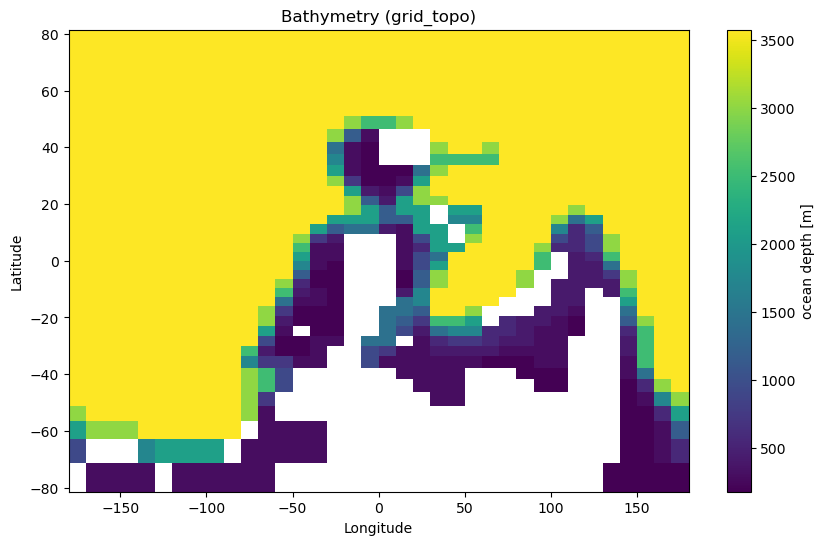

In [4]:
# === Basic Plotting of 2D Fields ===

# Plot bathymetry, output saved only in final time slice 
data_2d['grid_topo'].plot()
plt.title("Bathymetry (grid_topo)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

# Example: Plot sea surface temperature at final time slice (if multiple time steps exist) from dataset_path2
# 
# data_2d['ocn_sur_temp'][9].plot() # to plot the final timeslice (of 10), because python counts from 0
# plt.title("Surface Ocean Temperature (Final Time Slice)")
# plt.xlabel("Longitude")
# plt.ylabel("Latitude")
# plt.show()

#### Define plotting variables

 Assign netcdf variables a name to make easier to call later


In [5]:
##Define some variables you intend to plot, examples below

#SST = data_2d['ocn_sur_temp'][9] #if you have multiple time slices, index the time slice you want here. this is the 10th because python counts from zero
bathymetry = data_2d['grid_topo'] # otherwise if you save at only the final time slice no need for indexing
I_Ca = data_2d['proxy_sur_ICa']
I_Ca_2d = I_Ca.isel(time=0) # if you want contours you need to drop depth and time
ben_O2 = data_2d['ocn_ben_O2']
#sea_ice = data_2d['phys_seaice']
alk_ben = data_2d['ocn_ben_ALK']
alk_sur = data_2d['ocn_sur_ALK']
pH = data_2d['misc_pH']
bathymetry


topo = data_2d['grid_topo'].values.copy() # this is for making coastlines later
topo = np.where(np.isnan(topo), -1, topo)


### Colormaps

In [6]:
#define colormaps for plotting, use sequential for low-high, diverging for difference plots
cmap_bath = plt.get_cmap('YlGnBu') #use for bathymetry
cmap_SST = plt.get_cmap('RdBu_r') #use for SST
cmap_SST.set_over('#751a06') #use for SST scale bar
cmap_ICa = plt.get_cmap('viridis') #for surface proxies
cmap_ICa.set_bad("white") 
cmap_O2 = plt.get_cmap('cividis') #dissolved O2
cmap_O2.set_bad("white") # makes all nan values (e.g.landmass) white
cmap_ben_O2 = plt.get_cmap("BuPu_r")
cmap_MI = plt.get_cmap("plasma")


colors = [
    "#1b5e20",  # dark green
    "#4caf50",  # mid green
    "#8d6e63",  # light brown
    "#6d4c41",  # brown
    "#3e2723",  # dark brown
    "#eeeeee"   # high elevation light gray
]
# this is for topography overlay
topo_cmap = LinearSegmentedColormap.from_list("custom_topo", colors)


# some diverging color maps to choose from, all have light or white color middle
#sequential colormaps for differences that are only in pos or neg directions

cmap_temp_diff = plt.get_cmap('BrBG_r')
cmap_O2_diff = plt.get_cmap('seismic')


### 3D Field Data
 Import a single netcdf (fields_biogem_3d) file to visualize the map view of one simulation at **different vertical levels** of the ocean


In [7]:
# === Basic Plotting of 3D Fields ===
data_3d # has different attributes than _2d, see below

<xarray.Dataset> Size: 6MB
Dimensions:                   (time: 1, lon: 36, lat: 36, zt: 16, xu: 36,
                               yu: 36, lon_edges: 37, lat_edges: 37,
                               zt_edges: 17, xu_edges: 37, yu_edges: 37)
Coordinates:
  * time                      (time) float64 8B 1e+04
  * lon                       (lon) float64 288B -175.0 -165.0 ... 165.0 175.0
  * lat                       (lat) float64 288B -76.46 -66.44 ... 66.44 76.46
  * zt                        (zt) float64 128B 40.42 127.6 ... 4.604e+03
  * xu                        (xu) float64 288B -180.0 -170.0 ... 160.0 170.0
  * yu                        (yu) float64 288B -90.0 -70.81 ... 62.73 70.81
  * lon_edges                 (lon_edges) float64 296B -180.0 -170.0 ... 180.0
  * lat_edges                 (lat_edges) float64 296B -90.0 -70.81 ... 90.0
  * zt_edges                  (zt_edges) float64 136B 0.0 80.84 ... 5e+03
  * xu_edges                  (xu_edges) float64 296B -175.0 -165.0 ... 185.0
  * yu_edges                  (yu_edges) float64 296B -76.46 -66.44 ... 95.65
Data variables: (12/80)
    year                      (time) float32 4B ...
    grid_level                (lat, lon) float64 10kB ...
    grid_mask                 (lat, lon) float32 5kB ...
    grid_topo                 (lat, lon) float32 5kB ...
    grid_area                 (lat, lon) float32 5kB ...
    grid_mask_3d              (zt, lat, lon) float32 83kB ...
    ...                        ...
    grid_dD                   (time, zt, lat, lon) float32 83kB ...
    carb_d13C_CO2             (time, zt, lat, lon) float32 83kB ...
    carb_d13C_HCO3            (time, zt, lat, lon) float32 83kB ...
    carb_d13C_CO32            (time, zt, lat, lon) float32 83kB ...
    misc_proxy_d13C_LA1       (time, zt, lat, lon) float32 83kB ...
    misc_col_Dage             (time, zt, lat, lon) float32 83kB ...
Attributes:
    Conventions:      CF-1.0
    file_name:        ./biogem/fields_biogem_3d.nc
    title:            Time averaged integrals
    experiment_name:  
    time_unit:        Year mid-point

---
To either plot **meridional** or **zonal** vertical profile at a specific lat or lon *or* to plot the **map view of a specific depth** you need to subset the data_3d xarray as below.

Ocean depth ranges from 1 to 16 where 1 is the shallowest. These are the corresponding depths in meters for each z. Notice they are not uniform in thickness.

<div>
<img src="..\images\depths.jpg" width="500"/>
</div>

In [86]:
# ==== Indexing 3D fields data

# Select the tracer variable of interest (e.g., O2, age, etc.)
tracer_3d = data_3d['ocn_O2']     # dissolved oxygen
# tracer_3d = data_3d['ocn_DOM_P']
# tracer_3d = data_3d['ocn_PO4']

#----- If your dataset contains only one time slice (e.g., saved at the end), remove the time dimension by averaging across it
tracer_3d = tracer_3d.mean(dim='time') # you could jus index it below but getting rid of it makes it easier

###### Extract a horizontal map at a specific depth layer
# Syntax: tracer_3d[layer_index, lat, lon]
# Layer index ranges from 1 (shallowest) to 16 (deepest)
tracer_3d_map = tracer_3d[2, :, :]    # Adjust the index as needed

# redefine grid topography for 3d
# make zt = to tracer_3d_map value
topo_3d = data_3d['grid_mask_3d'].isel(zt = 1).values.copy() # this is for making coastlines later

topo_3d = np.where(np.isnan(topo_3d), -1, topo_3d)

###### Extract a vertical profile (e.g., meridional or zonal slice)
# Syntax: tracer_3d[depth, lat, lon] 
tracer_3d_prof = tracer_3d[:, :, 14]  # Example: meridional section at longitude index 14

#----- If your dataset has multiple time slices, comment out the `.mean(dim='time')` line above
# and instead select a specific time index like this:
# tracer_3d_vert = tracer_3d[9, :, :, 14]  # Syntax: [time, depth, lat, lon]




# Proxy Data Upload


You can either 

1) manually select points from the grid and save it into an object, or  
2) you can upload a file containing the data.



## 1) Manual Site Selection

cGenie 36 x 36 grid ([chapter 3 muffin manual](https://www.seao2.info/cgenie/docs/muffin.pdf)) to help you decide what lat or lon selection you want. The numbers in the grid cells are the depth at that location (zt) in this configuration.

<div>
<img src="..\images\cgenie36x36grid.png" width="500"/>
</div>

It is important to remember that python counts from 0. So the indexes range from 0 to 35 not 1 to 36

11.212271417649688 145.0


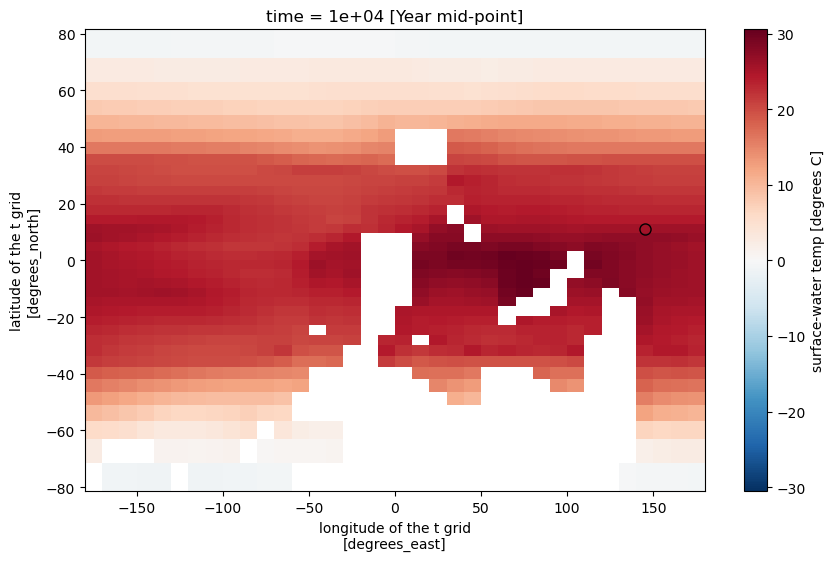

In [9]:
#===== Manual site selection, plot a point on the native grid 

# make a point where the yellow cell is in above grid
lat = data_2d['lat'][21].item() # 145 deg
long = data_2d['lon'][32].item() # 11.2 deg

print(lat, long)

# plot simple overlay over map of SST 

data_2d['ocn_sur_temp'].plot(cmap="RdBu_r") 

plt.plot(long, lat, marker='o', color='black', markerfacecolor='none', markersize=8)



Get the value of the point you plotted

In [10]:
value = data_2d['ocn_sur_temp'].isel(lat=21, lon=33).item()

# give the site a name
site_name = "site 1"

arr = np.array([lat,long,value, site_name], dtype=object) 

print(f"The SST at {arr[3]} [({round(arr[0],1)}, {round(arr[1],1)})] is {round(arr[2],2)} degrees")


The SST at site 1 [(11.2, 145.0)] is 25.91 degrees


## 2) Import site data from file

A more efficient way of doing this would be to save proxy data before and after event into one file because all other elements should be the same...maybe future me will do this because I would need o fix things downstream

In [11]:
# import proxy or location data from file
sites_df = pd.read_csv('../data_files/geochemical/sites_ICa_Bkgd.txt', sep='\t')

sites_df['label'] = sites_df['label'].astype(str)

sites_label =sites_df['label'] # save labels to use as overlay for figures

sites = sites_df.to_numpy()

print(f"Background proxy data is \n {sites}")

sites_df_KW = pd.read_csv('../data_files/geochemical/sites_ICa_KW.txt', sep='\t')

sites_df_KW['label'] = sites_df_KW['label'].astype(str) 

sites_KW = sites_df_KW.to_numpy()



Background proxy data is 
 [[-55.1 -18.16 1.02 'DG']
 [-36.6 -27.68 2.25 'BQ']
 [6.85 -17.61 2.97 'SS']
 [104.29 -0.53 3.26 'FH']]


Print out details about the spatial relationship of the data to the model grid. Because cGENIE is 36x36 the nearest grid point is likely not the same as the actual paleocoordinate. If grid topography at your site is nan it is plotting over a landmass and will not be included in data-model comparison and you will want to manually move it (see below). As demonstrated in this cell.

In [12]:
# test for proper placement of locality data

site_coords = np.delete(sites, [2, 3], axis=1)

# Make an empty array to store the nearest model grid point coordinates
nearest_grid_point_array = np.zeros((len(site_coords), 2))

def site_details(site_coords):  # Ensure the function takes site_coords correctly
    for i, site in enumerate(site_coords):  
        lon, lat = site  # Unpack longitude and latitude

        # Find the nearest grid point
        nearest_grid_point = data_2d.sel(lat=lat, lon=lon, method='nearest')
        
        # Store the nearest grid point coordinates in the array
        nearest_grid_point_array[i, 0] = nearest_grid_point.lon.values
        nearest_grid_point_array[i, 1] = nearest_grid_point.lat.values
        
        # Extract grid topography at the site
        grid_topo_at_site = nearest_grid_point.grid_topo.values

        print(f"Grid topography at site ({lon}, {lat}): {grid_topo_at_site}")

site_details(site_coords)


Grid topography at site (-55.1, -18.16): 728.831298828125
Grid topography at site (-36.6, -27.68): 283.8467102050781
Grid topography at site (6.85, -17.61): 1426.4306640625
Grid topography at site (104.29, -0.53): nan


We can see that the FH point is plotting over the landmass resulting in a nan. To move this point we can either change the data file and rerun everything or we can modify it here because we saved it as an array. We want to move it over to the left side of the landmass.

In [13]:
# move location of sites, if necessary

# Modify values in 'sites' before deleting columns
sites[3, 0] = 99 # Change first column of row 3 (longitude)
sites_KW[3, 0] = 99  # do same for other file

#sites[0, 1] = -15.5  # Change second column of row 0, changes laitude
#sites_KW[0, 1] = -15.5

print(sites)  # Check modifications

# Drop columns 2 and 3
site_coords = np.delete(sites, [2, 3], axis=1)

# Create an empty array for nearest grid points
nearest_grid_point_array = np.zeros((len(site_coords), 2))

# Call the function with the modified dataset
site_details(site_coords)

#you can save it if you want
#np.savetxt("sites_kw_adjusted.csv", sites_KW, delimiter=",", fmt="%s")

[[-55.1 -18.16 1.02 'DG']
 [-36.6 -27.68 2.25 'BQ']
 [6.85 -17.61 2.97 'SS']
 [99 -0.53 3.26 'FH']]
Grid topography at site (-55.1, -18.16): 728.831298828125
Grid topography at site (-36.6, -27.68): 283.8467102050781
Grid topography at site (6.85, -17.61): 1426.4306640625
Grid topography at site (99, -0.53): 2520.052734375


You will be using the modified **site_coords** array to plot data in mapview

### Import Large Observation dataset

Here I have a collection of proxy data and want the sites to be colored according to a value in another column in the file. I want black to equate to 'anoxia', grey to 'hypoxia', and white to 'oxic'. I also want different shapes for bottom and surface water proxies. 

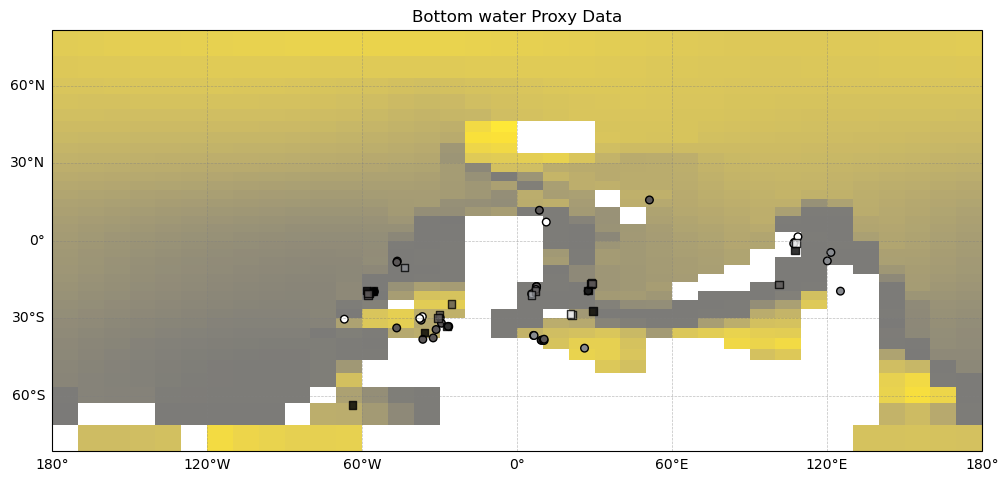

In [14]:
#save data into bottom and water column proxy type, I did not bother to make this pretty. 

df_bottom = pd.read_csv('../data_files/geochemical/FF sites.csv', encoding='unicode_escape')
df_bottom = df_bottom[df_bottom['Depth range of anoxia'] == "bottom"].copy()

df_column = pd.read_csv('../data_files/geochemical/FF sites.csv', encoding='unicode_escape')
df_column = df_column[df_column['Depth range of anoxia'] != "bottom"].copy()

# Replace NaNs with 0 in coordinate columns
for df in [df_bottom, df_column]:
    df['UKW (370 Ma) Paleocoord (Long)'] = df['UKW (370 Ma) Paleocoord (Long)'].fillna(0)
    df['UKW (370 Ma) Paleocoord (LAT)'] = df['UKW (370 Ma) Paleocoord (LAT)'].fillna(0)

# get coordinates
lon_b = df_bottom['UKW (370 Ma) Paleocoord (Long)']
lat_b = df_bottom['UKW (370 Ma) Paleocoord (LAT)']
color_b = df_bottom['Color'].astype(str)

lon_c = df_column['UKW (370 Ma) Paleocoord (Long)']
lat_c = df_column['UKW (370 Ma) Paleocoord (LAT)']
color_c = df_column['Color'].astype(str)

# Plot

fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add coastlines and grid

gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False


ben_O2.plot(cmap=cmap_O2, add_colorbar=False) # plot benthic O2

# Plot bottom sites as circles
points = ax.scatter(lon_b, lat_b, transform=ccrs.PlateCarree(), marker='o',
                    color=color_b, s=30, edgecolor='black', label='Bottom')

# Plot column sites as squares
points_col = ax.scatter(lon_c, lat_c, transform=ccrs.PlateCarree(), marker='s',
                       color=color_c, s=30, alpha=0.8, edgecolor='black', label='Column')

plt.title('Bottom water Proxy Data')
plt.show()

# Ploting 2D fields 

### Mapviews (surface or benthic features)

<a name="cell-2dmap"></a>Plot 2d map view of 2d field saved in data_2d xarray, below is an example. If you want to plot something else use the
[Guide to Colomaps](https://matplotlib.org/stable/gallery/color/colormap_reference.html) to pick an appopriate colormap. Follow the comments to change each line accordingly. 

This is plotting the sites in sites_coords with its nearest grid point in cGenie. When you do statistical analyses this is the grid cell in cGenie that you will be comparing to that site. If you don't like it change it above. 

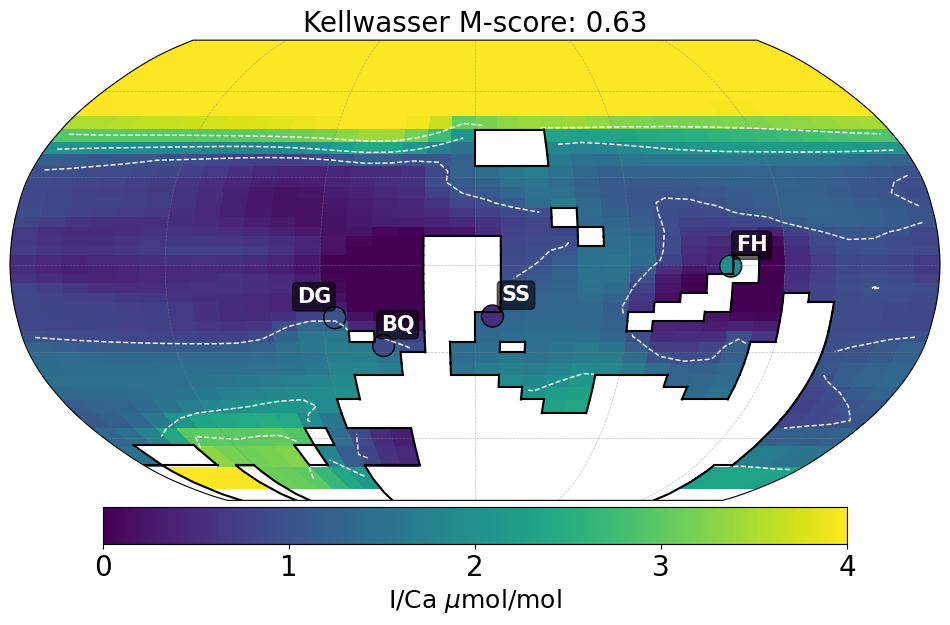

In [15]:
#2d field map of surface, benthic or specific ocean layer

#-------------------------------------------------------#
#Define plotting area and variable to plot
subplot_kws=dict(projection=ccrs.Robinson(),
                 facecolor='white')

plt.figure(figsize=[12,8]) # change size of figure


p = I_Ca.plot(x='lon', y='lat', #change variable whatever you defined above, if want to plot certain level in ocean plot tracer3d
                  vmin=0, vmax = 4, #change min and max if desired
                  cmap=cmap_ICa,#change color map depending on variable
                  subplot_kws=subplot_kws,
                  transform=ccrs.PlateCarree(),
                  add_labels=False,
                  add_colorbar=False)
#--------------------Add Contours------------------------#
# coastlines
#define meshgrid from lon/lat_edges in data_2d
ax = p.axes

# certain values


stepped_coastline_cGENIE(data_2d['lon_edges'], data_2d['lat_edges'],
                          ccrs.PlateCarree(),
                          topo,
                          1.5,
                          zorder=41)

# contours of specific values

# Contour on interpolated grid
#contours take contour([x,y], z) where z contains [x,y] and are arrays. 
#Cannot have time or depth domains remaining, meaning you need to squeeze() them out

contour = I_Ca_2d.plot.contour(ax=ax,
                             x='lon', y='lat',
                             levels=[1, 2, 3],
                             colors=['white'],
                             linestyles='dashed',
                             linewidths=1,
                             transform=ccrs.PlateCarree(),
                             add_labels=True)


#------------------------------------------------------------#
#aspects of color bar depending on what you are plotting #change ticks if  you want different increments,
# cb = plt.colorbar(p, ticks=[0, 500,  1000, 1500,  2000, 2500, 3000, 3500, 4000] , shrink=0.6)  #bathymetry
#cb = plt.colorbar(p, ticks=[0,4,8,12,16,20,24,28,32,36, 40], shrink=0.6) #change to this if you want SST
cb = plt.colorbar(p, ticks=[0,1,2,3,4], shrink = 0.8, location = "bottom", pad = 0.01)
cb.ax.tick_params(labelsize=20)
#cb = plt.colorbar(p, ticks=[0,.0001,.0002,.0003], shrink=0.6)
# cb=plt.colorbar(p)

# cb.set_label('Bathymetry (m)', fontsize=18) #colorbar title 
#cb.set_label(r'SST (°C)', fontsize=18)
cb.set_label(r'I/Ca $\mu$mol/mol', fontsize=18)

#cb.ax.tick_params(labelsize=18)
#-------------------------------------------------------#

#overlay the sites, comment out if don't want site overlay,  c=sites[:,2], vmin=0, vmax=4, cmap=fmap, if you want to color the symbols by value
p.axes.gridlines(draw_labels=False, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')

#simplest plotting, as shape with solid color
# site = plt.scatter(x = site_coords[:,0], y = site_coords[:,1], 
#             edgecolor = 'black',
#             c = 'black', 
#             marker = 'o', 
#             transform=ccrs.PlateCarree(), 
#             s = 100,
#                   zorder = 6) 

# plot nearest grid point and uncorrected site locations to show offset
# plt.scatter(x = sites[:,0], y = sites[:,1], edgecolor = 'black', c = 'white', marker = 'o', transform=ccrs.PlateCarree(), s = 75) 

# grid_cell = plt.scatter(x = nearest_grid_point_array[:,0], 
#             y = nearest_grid_point_array[:,1], 
#             facecolors='none', 
#             edgecolor = 'red',
#             marker = 's', 
#             transform=ccrs.PlateCarree(), 
#             s = 100,
#            linewidth = 2.5,
#                        zorder = 5) #plots the center of the nearest grid point that will be used for data comparison

#Plot points colored by value
plt.scatter(x = site_coords[:,0], y = site_coords[:,1], c = sites_KW[:,2], cmap = cmap_ICa, vmin=0, vmax=4, edgecolor = 'black', marker = 'o', transform=ccrs.PlateCarree(), s = 250) 

#------------------------------------------------------#


#print labels for sites
offsets = [(-15, 15), (10, 15), (17, 15), (15, 15)]   # cycle through these

for i, txt in enumerate(sites_label):
    ox, oy = offsets[i % len(offsets)]
    ax.annotate(txt, (site_coords[i,0], site_coords[i,1]),
                xycoords=ccrs.PlateCarree()._as_mpl_transform(ax),
                fontsize=15,
                textcoords="offset points",
                xytext=(ox, oy),
                ha="center",
                va="center",
                fontweight='bold',
                color='white',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.6))


#### plot labels over landmasses
# plt.annotate("Gondwana", (2, -70), fontsize = 10, transform=ccrs.PlateCarree())

# plt.annotate("Euramerica", (-17, -21), fontsize = 10, transform=ccrs.PlateCarree(), rotation = 60)

# plt.annotate("South China", (65, -30),fontsize = 10, transform=ccrs.PlateCarree(), rotation=20)

# plt.annotate("Siberia", (0, 40),fontsize = 10, transform=ccrs.PlateCarree())

# plt.legend(['I/Ca'])
# plt.legend([site, grid_cell], ['Site', 'Nearest grid point']) #if plotting mutliple type of points
plt.title('Kellwasser M-score: 0.63', fontsize =20)

#----------------------------------------------# 
# remember to deselect this after saving
# plt.savefig('../figures/bathymetry.png', dpi=300, bbox_inches='tight')
# plt.savefig('../figures/Ica_kellwasser.png', dpi=300, bbox_inches='tight')


plt.show()

### Interpolated plot with topography overlay

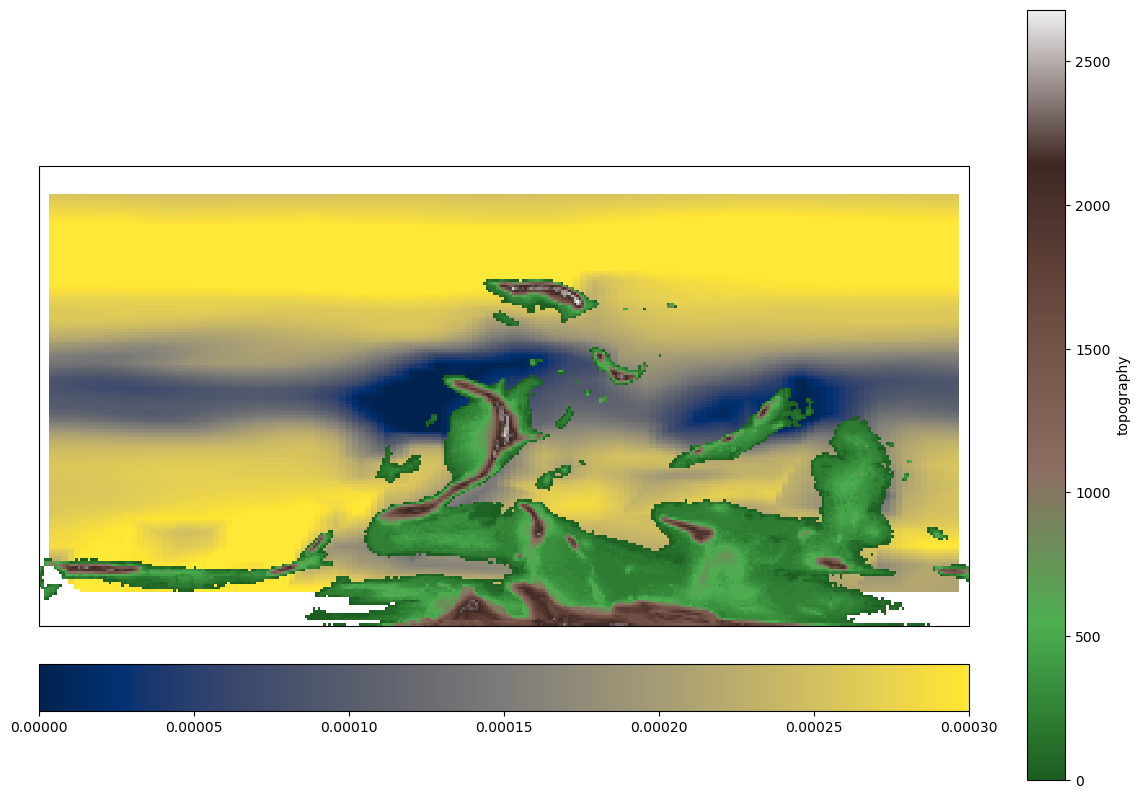

In [16]:
land = xr.open_dataset(r"..\data_files\georeferenced\topography_380Ma.nc")

depths = [1]
sub_O2 = data_3d['ocn_O2'].isel(zt = depths)

#mask very large numbers 
sub_O2 = sub_O2.where(sub_O2 < 1e34) # set to whatever the landmask value is, if nan set very low

# Original grid
sub_O2 = sub_O2.squeeze() # drops dimensions of 1 size (eg. time and zt)
lon2d, lat2d = np.meshgrid(sub_O2.lon, sub_O2.lat)

# Remove NaNs
valid = ~np.isnan(sub_O2.values)
points = np.column_stack([lon2d[valid], lat2d[valid]])
values = sub_O2.values[valid]

# New finer grid
new_lon = np.linspace(sub_O2.lon[0].item(), sub_O2.lon[-1].item(), sub_O2.sizes["lon"] * 4)
new_lat = np.linspace(sub_O2.lat[0].item(), sub_O2.lat[-1].item(), sub_O2.sizes["lat"] * 4)
new_lon2d, new_lat2d = np.meshgrid(new_lon, new_lat)

# Interpolate. make new dataarray to plot below
O2_interp = griddata(points, values, (new_lon2d, new_lat2d), method="linear")

dsi = xr.DataArray(O2_interp,
                   coords={"lat": new_lat, "lon": new_lon},
                   dims=["lat", "lon"])


#plot
fig, ax = plt.subplots(figsize=(15, 10),
                       subplot_kw={'projection': ccrs.PlateCarree(central_longitude=0)})

map_O2 = dsi.plot(ax=ax,                      
                  vmin=0,
                  vmax=0.0003,
                  cmap=cmap_O2,               
                  add_labels=False,
                  add_colorbar=False,
                  transform=ccrs.PlateCarree())

# land.plot(ax=ax, color='None', edgecolor='black', zorder=1,
#           transform=ccrs.PlateCarree())

land['topography'].plot(ax=ax, zorder = 2, cmap = topo_cmap, transform=ccrs.PlateCarree())


fig.colorbar(map_O2, ax=ax, location="bottom", pad =0.05)

plt.show()

### Contour maps
of circulation features (e.g. overturning streamfunctions) which is stored in 2d_fields

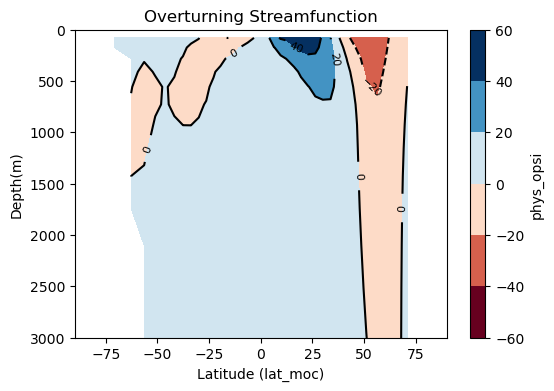

In [17]:
#data_2d["phys_opsi"].plot(yincrease=False) # default plotting
#plt.ylim(3000,0)

#make it pretty 
f = data_2d["phys_opsi"].mean(dim="time") # this is defined separaetly because it is technically 2d

fig, ax = plt.subplots(figsize=(6, 4))

cmap = plt.get_cmap("RdBu").copy()
#not sure why set_bad is not working to make landmass greay

# filled contours (with colors)
cf = f.plot.contourf(ax=ax, yincrease=False, cmap=cmap, add_colorbar=True)

# Plot overlayed contour lines
cs = f.plot.contour(ax=ax, yincrease=False, colors="black")
ax.clabel(cs, inline=True, fontsize=8)

ax.set_xlabel("Latitude (lat_moc)")
ax.set_ylabel("Depth(m)")
ax.set_title("Overturning Streamfunction")
ax.set_ylim(3000, 0) # Reverse y-axis (again)

#plt.savefig('..figures/.png', dpi=300, bbox_inches='tight')

plt.show()

### Plot Wind Fields 

To plot wind fields you need the wind stress in N m-2 and convert to velocity to scale the vectors.

In [18]:
# assign u and v stress components from 2D fields 

u_stress = data_2d['phys_tau_u'].isel(time = 0) # remove the time component
v_stress = data_2d['phys_tau_v'].isel(time = 0)

lons = data_2d['lon']
lats = data_2d['lat']

print(u_stress)
print(lons)

<xarray.DataArray 'phys_tau_u' (lat: 36, lon: 36)> Size: 5kB
[1296 values with dtype=float32]
Coordinates:
    time     float64 8B 1e+04
  * lon      (lon) float64 288B -175.0 -165.0 -155.0 ... 155.0 165.0 175.0
  * lat      (lat) float64 288B -76.46 -66.44 -59.44 ... 59.44 66.44 76.46
Attributes:
    long_name:  wind stress (u)
    units:      N/m-2
<xarray.DataArray 'lon' (lon: 36)> Size: 288B
array([-175., -165., -155., -145., -135., -125., -115., -105.,  -95.,  -85.,
        -75.,  -65.,  -55.,  -45.,  -35.,  -25.,  -15.,   -5.,    5.,   15.,
         25.,   35.,   45.,   55.,   65.,   75.,   85.,   95.,  105.,  115.,
        125.,  135.,  145.,  155.,  165.,  175.])
Coordinates:
  * lon      (lon) float64 288B -175.0 -165.0 -155.0 ... 155.0 165.0 175.0
Attributes:
    axis:           X
    edges:          lon_edges
    long_name:      longitude of the t grid
    standard_name:  longitude
    units:          degrees_east


In [19]:
# convert to wind speed or don't it is not necessary it only changes to units
rho_air = 1.22  # kg/m³
Cd = 1.3e-3     # drag coefficient

u_wind = np.sign(u_stress) * np.sqrt(np.abs(u_stress) / (rho_air * Cd))
v_wind = np.sign(v_stress) * np.sqrt(np.abs(v_stress) / (rho_air * Cd))


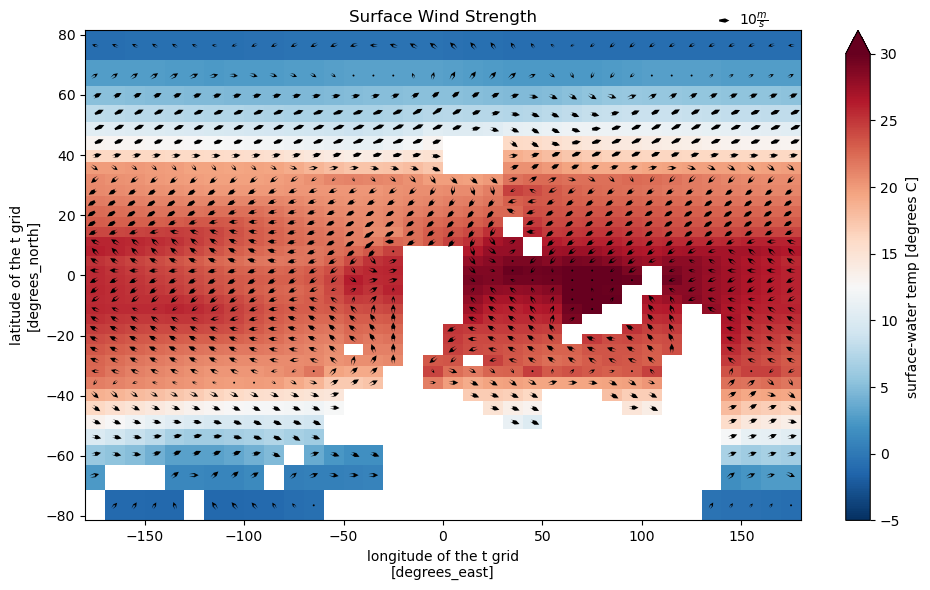

In [20]:
lon2d, lat2d = np.meshgrid(lons, lats)

# Create the figure and axes
fig1, ax1 = plt.subplots(figsize=(10, 6))

# Plot scalar field (tell xarray to use existing ax)
data_2d['ocn_sur_temp'].plot(ax=ax1, 
                             cmap='RdBu_r',
                            vmin=-5, vmax=30)

# Overlay wind vectors
Q = ax1.quiver(
    lon2d,
    lat2d,
    u_wind,
    v_wind,
    units='width',
    scale=700,            # adjust to match your data
    width=0.003,
    headwidth = 2,
    headlength=2,
    color='k'             # black arrows for contrast
)

# Add quiver key
ax1.quiverkey(
    Q, 0.9, 1.02, 10, r'$10 \frac{m}{s}$', labelpos='E',
    coordinates='axes'
)

# Set title and show plot
ax1.set_title("Surface Wind Strength")
plt.tight_layout()

#plt.savefig('../figures/.png', dpi=300, bbox_inches='tight')

plt.show()


### Latitudinal Gradients 


Import background (bkg) and event (ev) simulations. 

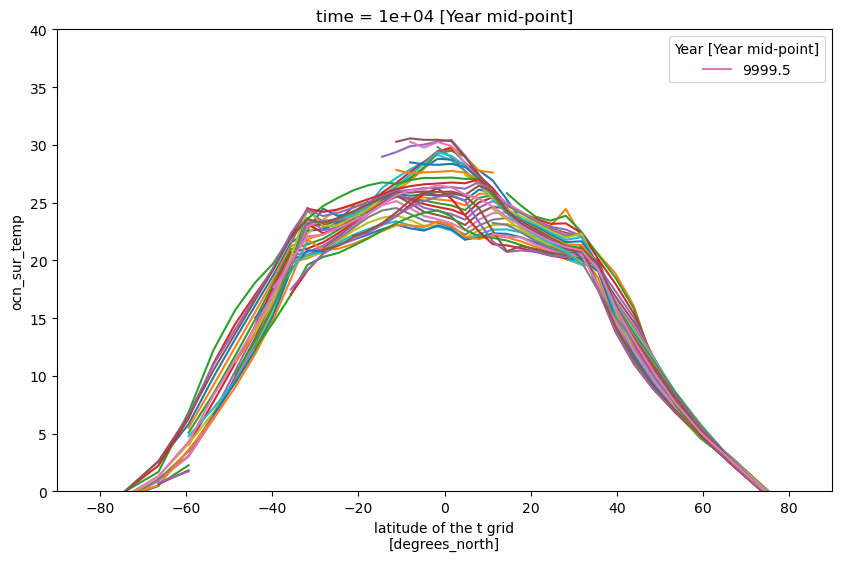

In [21]:
#plot zonal gradient of surface tracer
SST = data_2d['ocn_sur_temp']

SST_timeavg = SST.mean(dim='time') #this reduces itto a 2D xarray 
# print(SST_timeavg)

SST_timeavg.plot.line(x= 'lat')  #plot SST along all longitude

#subset just the latitude 

#zonal_SST = SST_timeavg[:,16]#SST[lat,lon]; for a latitudinal gradient at one long 18 is about half way 
zonal_SST = SST.mean(dim="lon", skipna=True) #plots average zonal gradient

zonal_SST.plot.line(x= 'lat', xlim= (-90,90), ylim = (0,40)) 
#plt.scatter(x = sites_SST[:,1] , y =sites_SST[:,2]) #add data sites, or don't 


In [22]:
# compare two conditions 

bkg_path = r"D:\Transitions\transition_15\background\251104.pO2xPO4_5x5a.dat.44.tar.gz"
ev_path = r"D:\Transitions\transition_15\kellwasser\Devon370Ma_075xRemin_1xpCO2.pO2xPO4_5x5c.dat.41.tar.gz"

bkg_2d, bkg_3d, bkg_2d_path, bkg_3d_path = unpak_single_tar(bkg_path)

kw_2d, kw_3d, kw_2d_path, kw_3d_path = unpak_single_tar(ev_path)


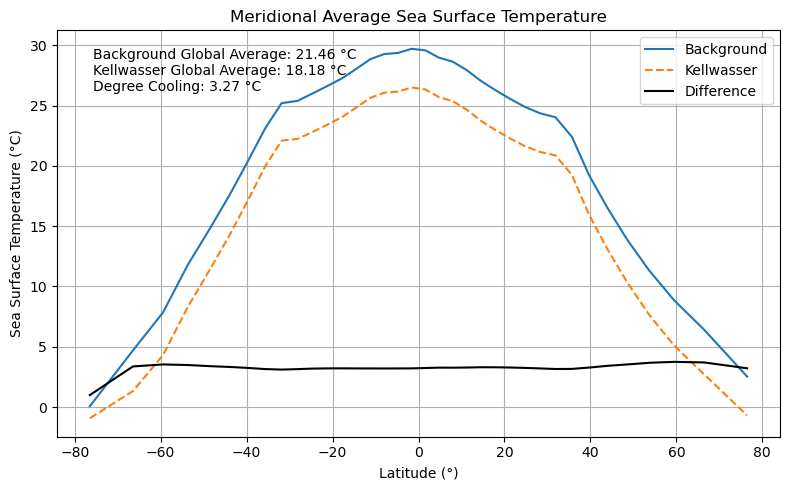

In [23]:
# remove time dimension
bkg_sst = bkg_2d['ocn_sur_temp'].isel(time=-1)
kw_sst  = kw_2d['ocn_sur_temp'].isel(time=-1)

# --- Meridional (latitudinal) means ---
bkg_sst_lat = bkg_sst.mean(dim="lon", skipna=True)
kw_sst_lat  = kw_sst.mean(dim="lon", skipna=True)

# --- Difference of meridional means ---
lat_diff = bkg_sst_lat - kw_sst_lat

# Calculate global average temp change (average across lat and lon and take difference)
bkg_mean = bkg_sst.mean(dim=("lat","lon"), skipna=True).item()
kw_mean  = kw_sst.mean(dim=("lat","lon"), skipna=True).item()
change   = bkg_mean - kw_mean

# --- Plot ---
plt.figure(figsize=(8,5))
bkg_sst_lat.plot.line(x='lat', label="Background")
kw_sst_lat.plot.line(x='lat', linestyle='--', label="Kellwasser")
lat_diff.plot.line(x='lat', color="k", label="Difference")

plt.text(
    0.05, 0.85, 
    f"Background Global Average: {bkg_mean:.2f} °C\n"
    f"Kellwasser Global Average: {kw_mean:.2f} °C\n"
    f"Degree Cooling: {change:.2f} °C", 
    transform=plt.gca().transAxes
)

plt.xlabel("Latitude (°)")
plt.ylabel("Sea Surface Temperature (°C)")
plt.title("Meridional Average Sea Surface Temperature")
plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.savefig("../figures/lat_sst_change.png")
plt.show()


In [24]:
## Calculate Metabolic Index

In [25]:
MI_values = pd.read_csv(r"D:\FRES_learning\data_files\Metabolic Index\phi_taxa_values.csv")
print(MI_values) 

               phylum  ao(median)  eo(mean)  phi_crit(median)
0            Cnidaria    9.960159  0.422600           1.54540
1    Mollusca_benthic   13.140604  0.215100           2.45370
2    Mollusca_pelagic   21.367521  0.304000           4.38290
3            Chordata   30.859332  0.584250           3.97725
4  Arthropoda_benthic   24.099884  0.312800           2.84695
5         Brachiopoda   60.800000  0.850000           1.00000
6       Echinodermata   38.600000  0.380000           1.00000
7             average   28.403929  0.438393           0.32145


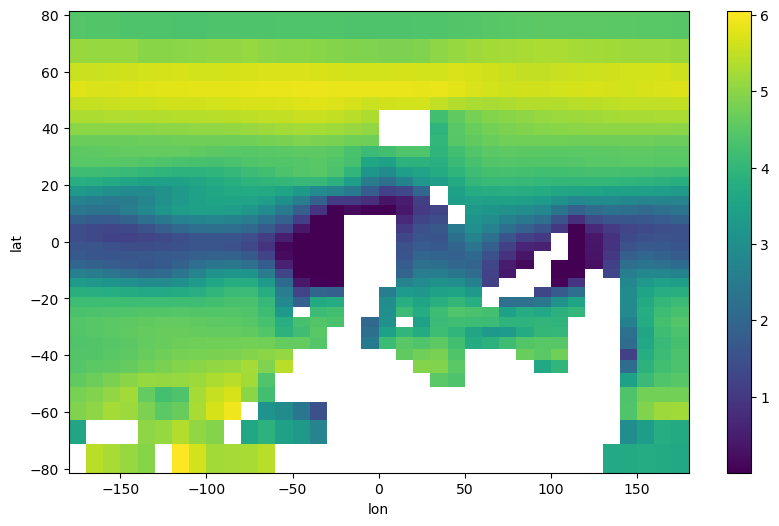

In [26]:
# ── MI calculation ────────────────────────────────────────────────────────────
avg_ao = MI_values.loc[MI_values["phylum"] == "average", "ao(median)"].item()
avg_eo = MI_values.loc[MI_values["phylum"] == "average", "eo(mean)"].item()
phi_crit = MI_values.loc[MI_values["phylum"] == "average", "phi_crit(median)"].item()

lat = bkg_3d['lat'].values
lon = bkg_3d['lon'].values

bkg_ocn_O2 = bkg_3d['ocn_O2'].isel(zt = 1).mean(dim = 'time')
bkg_ocn_temp = bkg_3d['ocn_temp'].isel(zt = 1).mean(dim = 'time')

kw_ocn_O2 = kw_3d['ocn_O2'].isel(zt = 1).mean(dim = 'time')
kw_ocn_temp = kw_3d['ocn_temp'].isel(zt = 1).mean(dim = 'time')

k_B = 8.617e-5

pO2_bkg   = bkg_ocn_O2.values / 1.28e-3     
temp_K_bkg = bkg_ocn_temp.values + 273.15
phi_bkg   = 4.5* pO2_bkg / (np.exp((-0.4 / k_B) * ((1 / temp_K_bkg) - (1 / 288))))
phi_da_bkg = xr.DataArray(phi_bkg,coords={"lat": lat, "lon":lon}, dims=["lat","lon"])


pO2_kw   = kw_ocn_O2.values / 1.28e-3     
temp_K_kw = kw_ocn_temp.values + 273.15
phi_kw   = 22* pO2_kw/ (np.exp((-0 / k_B) * ((1 / temp_K_bkg) - (1 / 288))))
phi_da_kw = xr.DataArray(phi_kw,coords={"lat": lat, "lon":lon}, dims=["lat","lon"])

MI_diff = phi_da_kw - phi_da_bkg

phi_da_kw.plot()


# Plotting 3D field data


With 3d field data you can plot map view of a certain depth in ocean (z_t), meridional and zonal profiles, and linear profiles at a specific site and/or depth

### Map view of specific ocean layer

Use tracer_3d_map defined in Data Import section. Right now it is set to plot dissolved oxygen (ocn_O2) at z = 3 (~230 m)

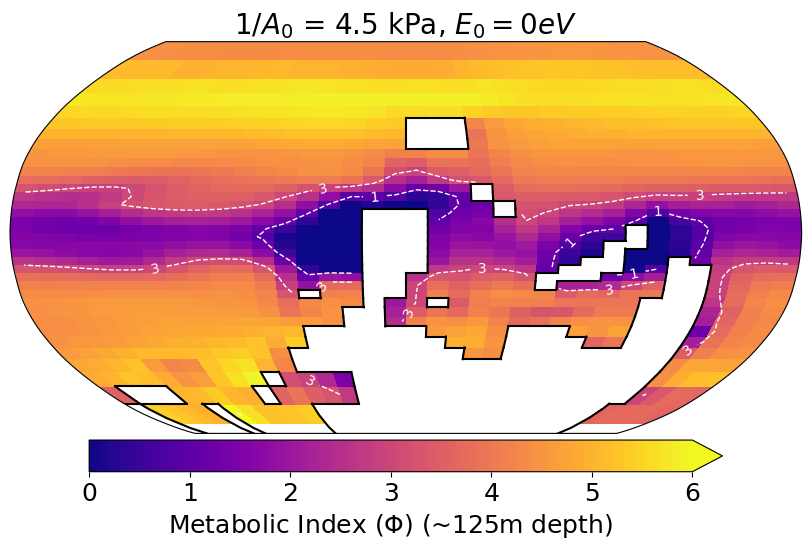

In [27]:
# go find tracer_3d_map in 3D Field Import section, modify depth layer

# Subplot settings 
subplot_kws = dict(projection=ccrs.Robinson(), facecolor='white')

# Create a single subplot
fig, ax = plt.subplots(figsize=(8, 6), layout = "constrained", subplot_kw=subplot_kws)

# Plot data on the map
p = phi_da_kw.plot( #tracer_3d_map
    x='lon', y='lat',
    vmin=0,
    vmax = 6, #you can either set this value to what you want, adding a digit after the last you want to appear in colorbar will make it scale to that value 
    # vmax = np.nanmax(tracer_3d_map), # this makes the highest colorbar value the largest value 
    # cmap= cmap_O2,#defined in 2D fields section
    cmap = "plasma",
    ax=ax,
    transform=ccrs.PlateCarree(),
    add_labels=False,
    add_colorbar=False
)

#--------map details
# ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--') #comment out if you don't want coordinates andgridlines

#--------------------Add Contours------------------------#
# coastlines
#define meshgrid from lon/lat_edges in data_2d
ax = p.axes

# certain values
stepped_coastline_cGENIE(data_3d['lon_edges'], data_3d['lat_edges'],
                          ccrs.PlateCarree(),
                          topo_3d,
                          1.5,
                          zorder=41)

# Contour on interpolated grid
contour = phi_da_kw.plot.contour(ax=ax, 
                             x='lon', y='lat',
                             # levels=[0, 0.0001, 0.0002, 0.0003],
                               levels=[1, 3, 6],
                             colors=['white'],
                             linestyles='dashed',
                             linewidths=1,
                             transform=ccrs.PlateCarree(),
                             add_labels=True)

ax.clabel(contour, inline=True, fontsize=10)


#---------------colorbar -------------
import matplotlib.ticker as mticker
cb = plt.colorbar(
    p, ticks=[0, 1, 2, 3, 4, 5, 6],
    extend="max", orientation='horizontal', pad = 0.01, shrink = 0.8
    # format=mticker.FuncFormatter(lambda x, _: f'{x*1e3:.1f}')
)
cb.set_label(r'$\times 10^{-6}$')

cb.ax.tick_params(labelsize=18)
# cb.set_label(r'[$O_{2}$] ($\mu$mol/kg)', fontsize=18)
cb.set_label(r'Metabolic Index ($\Phi$) (~125m depth)', fontsize=18)

#-----------------labels-------------
# Set subplot title
# ax.set_title('$[O_2]$ (~250m depth)', fontsize=20)
# plt.title('', fontsize =20)
ax.set_title(r'$1/A_{0}$ = 4.5 kPa, $E_{0} = 0 eV $ ', fontsize=20)

# plt.savefig('../figures/MI_E0_0_125m.png', dpi=300, bbox_inches='tight')

plt.show()

### Zonal and meridional profiles


Using the data stored in tracer_3d_prof. 

Text(0.5, 0, 'Latitude')

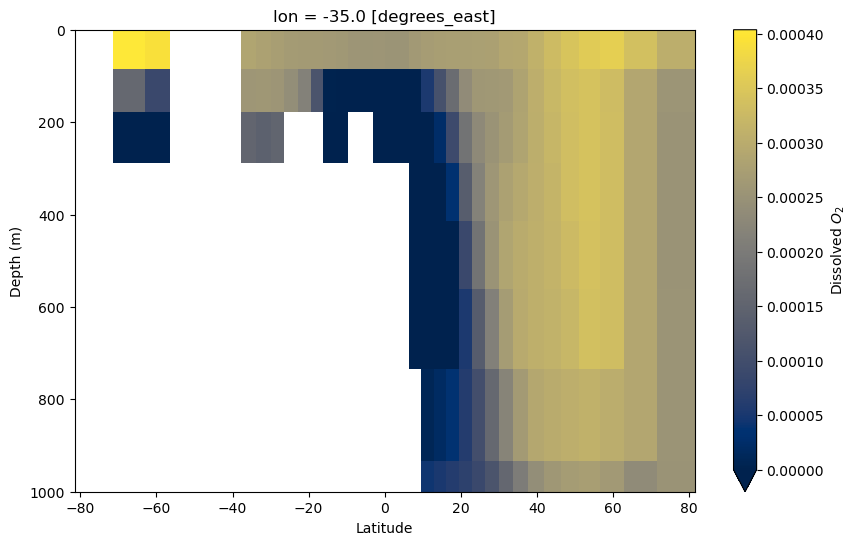

In [28]:
#make sure tracer_3d is saved as tracer_3d = tracer_3d[:,:,#], this plots specific longitude

#tracer_3d_vert = tracer_3d.mean(dim = 'lon', skipna =True) #average over all lon

tracer_3d_prof.plot(yincrease =False, #reversed the axis 
               cmap = cmap_O2, 
               vmin = 0 , 
               #vmax = 0.00015,
              cbar_kwargs={"label": "Dissolved $O_2$"}) # be sure to change tracer_3d to the tracer you want and the lat or long you want
plt.ylabel("Depth (m)")
plt.ylim(1000,0) # deeper value first because axis is reversed

plt.xlabel("Latitude")

Plot depth profile of a tracer at a specific site. 

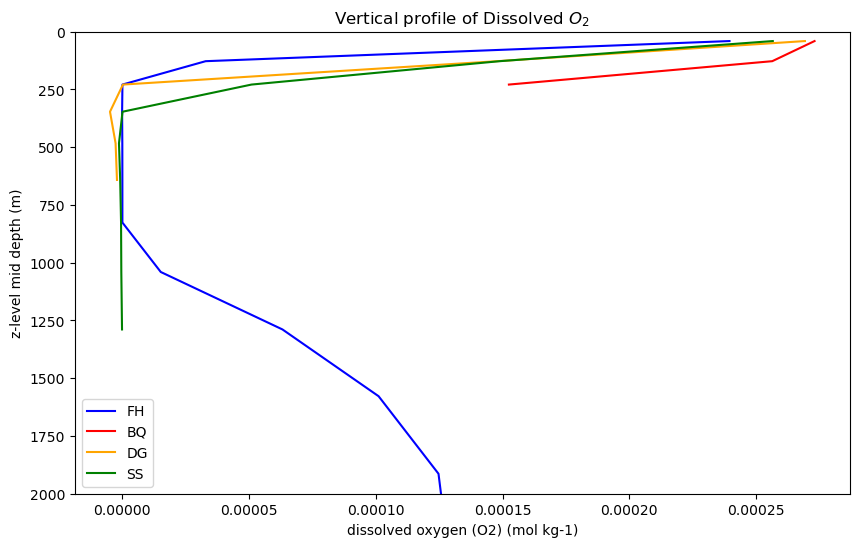

In [29]:
##---Depth Profiles

vert_data = data_3d['ocn_O2'] #save into new variable 

# save just the data for the nearest grid point at each site 
profile = vert_data.sel(lon=sites[:,0],lat=sites[:,1],method="nearest") # select your site
#print(profile)

#obviosuly change the site names to your sites 
DG = profile[0, :,0,0]
BQ = profile[0, :,1,1]
SS = profile[0, :,2,2]
FH = profile[0, :,3,3] # (time: 1, zt: 16, lat: 4, lon: 4) This selects the vertical profile at site 4 bc python likes to count from 0 


depthvar = data_2d['zt']
depthvals = depthvar[:]
plt.xlabel(FH.long_name   + ' (' + FH.units   + ')') #you just need the xlabel from one of the sites
plt.ylabel(depthvar.long_name + ' (' + depthvar.units + ')')
plt.ylim(0,2000)
plt.gca().invert_yaxis()
plt.plot(FH, depthvals, label = "FH", color ='blue') #could be improved with different line types
plt.plot(BQ, depthvals, label = "BQ", color ='red')
plt.plot(DG, depthvals, label = "DG", color ='orange')
plt.plot(SS, depthvals, label = "SS", color ='green')
plt.legend(loc='lower left')
plt.title('Vertical profile of Dissolved $O_{2}$')
plt.show()


# Difference plots 

Plot the spatial differences in tracers fields between **two different simulations** 

In [30]:
# define what difference you want to observe 

#bkd_2d and kw_2d are defined in Latitudinal gradients section

#for 2d, make sure use biogem.fields 2d-------------------------------------
#kellwasser - background to signifying degrees of cooling
# diff_2d =  kw_2d['ocn_sur_temp'].isel(time = 0) - bkg_2d['ocn_sur_temp'].isel(time = 0) 

diff_2d =  kw_2d['ocn_sur_temp'].isel(time = 0) - bkg_2d['ocn_sur_temp'].isel(time = 0) 

#for 3d----------------------------

diff_3d = kw_3d['ocn_temp'].isel(time = 0, zt = 1) - bkg_3d['ocn_temp'].isel(time = 0, zt = 1) 

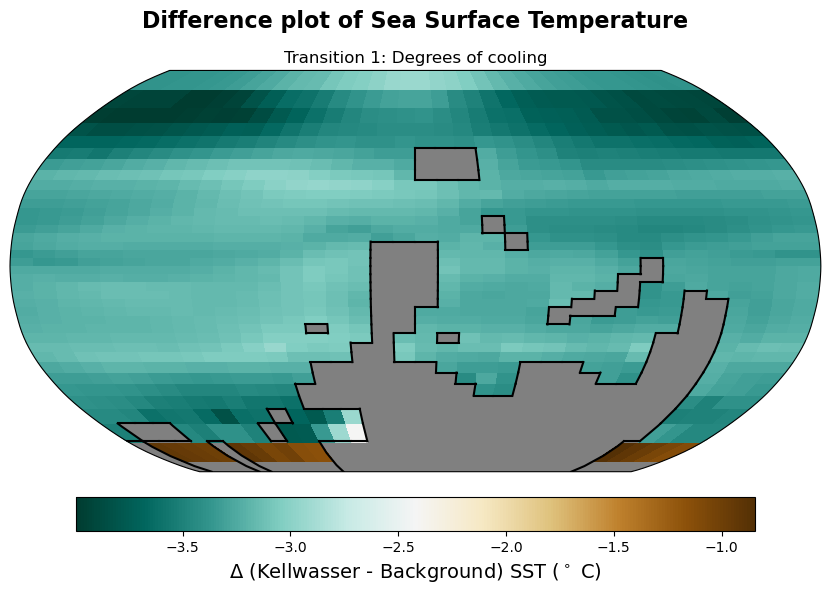

In [31]:

fig = plt.figure(figsize=(10,6))
ax = plt.axes(projection=ccrs.Robinson())
ax.set_facecolor('grey')

# Plot the xarray data onto the axis
a = diff_2d.plot(
    ax=ax,
    x='lon', y='lat',
    # vmin = 3, 
    # vmax = 6, 
    cmap="BrBG_r",
    transform=ccrs.PlateCarree(),
    add_colorbar=False
)


stepped_coastline_cGENIE(data_2d['lon_edges'], data_2d['lat_edges'],
                          ccrs.PlateCarree(),
                          topo,
                          1.5,
                          zorder=41)

# Contour 
# contour = diff_2d.plot.contour(ax=ax,
#                              x='lon', y='lat',
#                              levels=[5, 6, 7],
#                              colors=['white'],
#                              linestyles='dashed',
#                              linewidths=1,
#                              transform=ccrs.PlateCarree(),
#                              add_labels=False)

# ax.clabel(contour, inline=True, fontsize=10)

# Overlay scatter plot
# sc = ax.scatter(
    # x=site_coords[:, 0], y=site_coords[:, 1],
    # c=sites_diff, cmap=cmap,
    #vmin=-3, vmax=3,
    # edgecolor='black', marker='o', s=75,
    # transform=ccrs.PlateCarree()
# )

cbar = fig.colorbar(a, ax=ax, orientation='horizontal', shrink=0.7, pad=0.05)
cbar.set_label('$\Delta$ (Kellwasser - Background) SST ($^\circ$ C)', fontsize=14)

plt.suptitle("Difference plot of Sea Surface Temperature", y=0.98, fontsize=16, fontweight='bold')
ax.set_title("Transition 1: Degrees of cooling", fontsize=12)

plt.tight_layout()
# plt.savefig('../figures/temp_diff_plot.png', dpi=300, bbox_inches='tight')
plt.show()


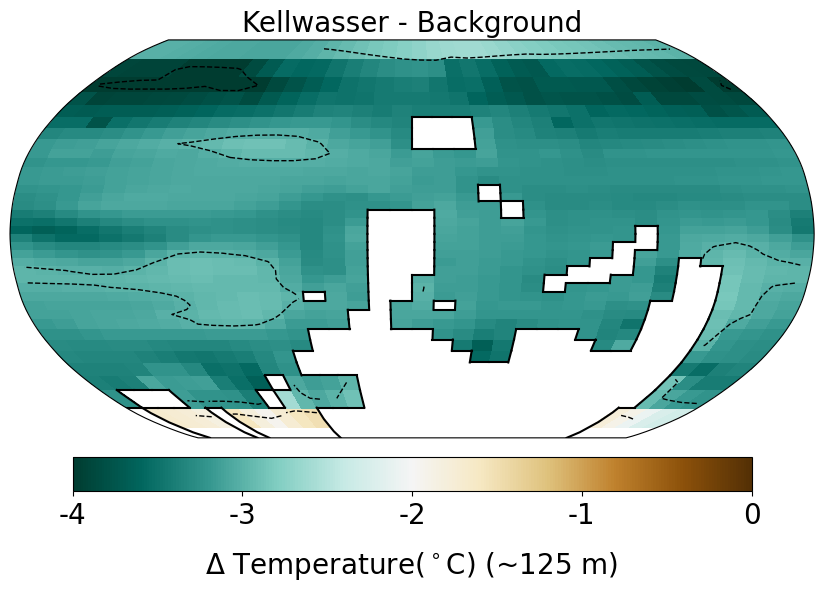

In [32]:
topo_3d = data_3d['grid_mask_3d'].isel(zt = 1).values.copy() # this is for making coastlines later

topo_3d = np.where(np.isnan(topo_3d), -1, topo_3d)


# Set up figure and axis with cartopy projection
fig = plt.figure(figsize=(10,6))
ax = plt.axes(projection=ccrs.Robinson())
ax.set_facecolor('white')

# Plot the xarray data onto the axis
a = diff_3d.plot(
    ax=ax,
    x='lon', y='lat',
    # vmin = -1e-06, vmax = 1e-06, #scale to the difference in observational values rounded up/down, comment whole line if not using points
    vmin = -4, vmax= 0,
    cmap=cmap_temp_diff,
    transform=ccrs.PlateCarree(),
    add_colorbar=False
)
stepped_coastline_cGENIE(data_3d['lon_edges'], data_3d['lat_edges'],
                          ccrs.PlateCarree(),
                          topo_3d,
                          1.5,
                          zorder=41)

# Contour 
contour = diff_3d.plot.contour(ax=ax,
                             x='lon', y='lat',
                             levels=[0,-1, -2, -3, -4],
                             colors=['black'],
                             linestyles='dashed',
                             linewidths=1,
                             transform=ccrs.PlateCarree(),
                             add_labels=True)

# ax.clabel(contour, inline=True, fontsize=10) # add contour label

# Overlay scatter plot
# sc = ax.scatter(
#     x=site_coords[:, 0], y=site_coords[:, 1],
#     # c=sites_diff, cmap=cmap,
#     # vmin=-3, vmax=3,
#     color = 'black',
#     edgecolor='black', marker='o', s=100,
#     transform=ccrs.PlateCarree()
# )

# Add a tightly controlled horizontal colorbar
cbar = fig.colorbar(a, ax=ax, orientation='horizontal', shrink=0.7, pad=0.04, format='%.0f',  ticks=[0, -1, -2, -3,-4])
# cbar.set_label('$\Delta$ [$O_{2}$] ($\mu$mol/kg) (~125 m)', fontsize=20, labelpad=15)
cbar.set_label('$\Delta$ Temperature($^\circ$C) (~125 m)', fontsize=20, labelpad=15)
cbar.ax.tick_params(labelsize= 20)
# cbar.formatter = FuncFormatter(lambda x, pos: f"{x / 1e-05:.0f}")
cbar.update_ticks()



# Titles
# plt.suptitle("Difference plot of Dissolved O2", y=0.98, fontsize=16, fontweight='bold')
ax.set_title("Kellwasser - Background", fontsize=20)


plt.tight_layout()  # Helps layout elements without excessive whitespace
# plt.savefig('../figures/temp_diff_plot.png', dpi=300, bbox_inches='tight')
plt.show()



# Plot time series data

Time series data exists in the biogem folder. 

In [33]:
#import and save time series into ts_varaible, here I import global SST and save as a dataframe

 #start by designating column names

column_names = ["Time (yr)", "Temperature (C)", "_surT (ice-free) (C)", "_benT (C) [> 2000 m]", "_surT (C)"] 
time_series = pd.read_csv("../genie-output/Single_Experiment/single_time_slice/simulation_1/Devon370Ma_1xRemin_1xpCO2.pO2xPO4_5x5b.dat.33/biogem/biogem_series_ocn_temp.res", #navigate to whatever folder you want to plot,
                          delim_whitespace=True, names=column_names, skiprows=1)                            # here I plot an example that I saved in its own folder, Output



#these column names are silly, use janitor to tidy them
time_series = time_series.clean_names(strip_underscores=True)# this removes the leading underscores and converst everything to lowercase
time_series.head()


C:\Users\prowa\AppData\Local\Temp\ipykernel_34152\60709280.py:6: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  time_series = pd.read_csv("../genie-output/Single_Experiment/single_time_slice/simulation_1/Devon370Ma_1xRemin_1xpCO2.pO2xPO4_5x5b.dat.33/biogem/biogem_series_ocn_temp.res", #navigate to whatever folder you want to plot,


,time_yr,temperature_c,surt_ice_free_c,bent_c_[>_2000_m],surt_c
0,0.5,5.037724,7.156722,4.972847,7.156722
1,1.5,5.089833,9.861753,4.926438,9.848286
2,2.5,5.131336,11.469764,4.889707,11.411102
3,3.5,5.166127,12.492811,4.857965,12.410500
4,4.5,5.196462,13.230492,4.829545,13.100921


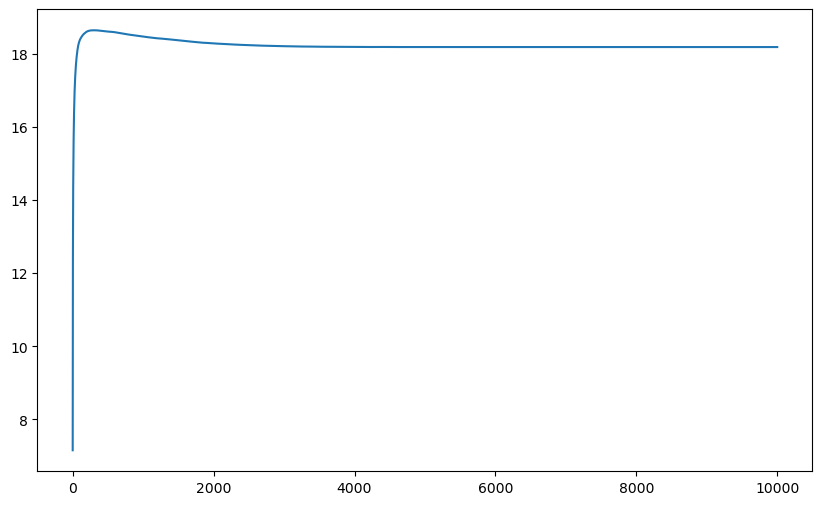

In [34]:
plt.plot(time_series["time_yr"], time_series["surt_c"])
plt.show()

# Ensembles

## Import ensemble data

In [78]:
def untar_all_to_temp(from_folder, to_folder="temp"):
    os.makedirs(to_folder, exist_ok=True)  # Create temp directory if needed

    tar_files = glob.glob(os.path.join(from_folder, "*.tar*"))  # Match .tar, .tar.gz, etc.

    for tar_path in tar_files:
        if tarfile.is_tarfile(tar_path):
            print(f"Extracting {os.path.basename(tar_path)} to {to_folder}")
            with tarfile.open(tar_path, 'r:*') as tar:
                tar.extractall(path=to_folder)  # Extract everything directly into temp
        else:
            print(f"Skipped (not a tar file): {tar_path}")

# untar_all_to_temp(r"..\manuscript_figure_files\PO4xpO2") # these have been untared already so it won't create a temp folder
untar_all_to_temp(r"..\genie-output\Ensemble\Devon370Ma_1xRemin_1xpCO2")

Extracting Devon370Ma_1xRemin_1xpCO2.pO2xPO4_5x5b.dat.00.tar.gz to temp
Extracting Devon370Ma_1xRemin_1xpCO2.pO2xPO4_5x5b.dat.01.tar.gz to temp
Extracting Devon370Ma_1xRemin_1xpCO2.pO2xPO4_5x5b.dat.02.tar.gz to temp
Extracting Devon370Ma_1xRemin_1xpCO2.pO2xPO4_5x5b.dat.03.tar.gz to temp
Extracting Devon370Ma_1xRemin_1xpCO2.pO2xPO4_5x5b.dat.04.tar.gz to temp
Extracting Devon370Ma_1xRemin_1xpCO2.pO2xPO4_5x5b.dat.10.tar.gz to temp
Extracting Devon370Ma_1xRemin_1xpCO2.pO2xPO4_5x5b.dat.11.tar.gz to temp
Extracting Devon370Ma_1xRemin_1xpCO2.pO2xPO4_5x5b.dat.12.tar.gz to temp
Extracting Devon370Ma_1xRemin_1xpCO2.pO2xPO4_5x5b.dat.13.tar.gz to temp
Extracting Devon370Ma_1xRemin_1xpCO2.pO2xPO4_5x5b.dat.14.tar.gz to temp
Extracting Devon370Ma_1xRemin_1xpCO2.pO2xPO4_5x5b.dat.20.tar.gz to temp
Extracting Devon370Ma_1xRemin_1xpCO2.pO2xPO4_5x5b.dat.21.tar.gz to temp
Extracting Devon370Ma_1xRemin_1xpCO2.pO2xPO4_5x5b.dat.22.tar.gz to temp
Extracting Devon370Ma_1xRemin_1xpCO2.pO2xPO4_5x5b.dat.23.tar.gz 

In [120]:
# import ensemble 2d and 3d fields data

df2d = {}

#this is a good one for examples, keep for git hub page but rename  
for name in glob.glob(r"..\genie-output\manuscript_figure_files\PO4xpO2\pO2xPO4_5x5.dat.*/biogem/fields_biogem_2d.nc"): 

  data = xr.open_dataset(name)

  df2d[name] = data
  
sorted_dict = dict(sorted(df2d.items()))

df2d = pd.DataFrame(sorted_dict.items(), columns=['file', 'content'])
#print(df2d)

df2d['file'] = df2d['file'].str.split('dat').str[-1]

df2d['file'] = df2d['file'].str.split('biogem').str[0]


df3d = {}
for name in glob.glob(r"..\genie-output\manuscript_figure_files\PO4vsefolding\pO2xPO4_5x5.dat.*/biogem/fields_biogem_3d.nc"):#change path
  #print(name)
  data = xr.open_dataset(name)
  df3d[name] = data
sorted_dict = dict(sorted(df3d.items()))

df3d = pd.DataFrame(sorted_dict.items(), columns=['file', 'content'])

df3d['file'] = df2d['file'].str.split('dat').str[-1]

df3d['file'] = df2d['file'].str.split('biogem').str[0]

print(df3d)



   file                                            content
0  .00\  [year, grid_level, grid_mask, grid_topo, grid_...
1  .01\  [year, grid_level, grid_mask, grid_topo, grid_...
2  .02\  [year, grid_level, grid_mask, grid_topo, grid_...
3  .10\  [year, grid_level, grid_mask, grid_topo, grid_...
4  .11\  [year, grid_level, grid_mask, grid_topo, grid_...
5  .12\  [year, grid_level, grid_mask, grid_topo, grid_...
6  .20\  [year, grid_level, grid_mask, grid_topo, grid_...
7  .21\  [year, grid_level, grid_mask, grid_topo, grid_...
8  .22\  [year, grid_level, grid_mask, grid_topo, grid_...


<div class="alert-warning">
<b>Important</b> for <i>plot_me_3d</i>: if you are plotting <u>map view </u>select the vertcal layer, if plotting <u> vertical profiles </u> uncomment the second value line in the tracer3d function.  
</div>

### Plot meeee!

In [121]:
%%capture
# define functions to subset 2d and 3d field data and save as objects plot_me_2d and plot_me_3d to work with

d_tracer = df2d.copy()

def tracer2d(field):
  for i in d_tracer['content'].index:
    value = d_tracer['content'][i]
    value = value[field]
    value = value.mean(dim = 'time') #use this if you only have one time slice
    #value = value[9] #use this if you have multiple time slieces to select the one you want
    #d_tracer['content'][i] = value
    d_tracer['content'].iloc[i] = value
    #d_tracer["content"][i] = value
  return d_tracer

d_tracer3d = df3d.copy()

def tracer3d(field):
  for i in d_tracer3d['content'].index:
    value = d_tracer3d['content'][i]
    value = value[field]
    value = value.mean(dim = 'time')
    value = value[1,:,:] # for 3d you must select layer, map view
    # value = value[:,:,:] # if you want to plot vertical profile
    d_tracer3d['content'].iloc[i] = value

  return d_tracer3d


#enter the variable you want to plot in the function, it will not let you rename it later. This is the only place you can assign it!!
plot_me_2d = tracer2d('proxy_sur_ICa') #common ones I use: proxy_sur_ICa, ocn_sur_temp, ocn_ben_O2, phys_seaice

#plot_me_2d = tracer2d('ocn_ben_O2') # needed for calculating global areal extent benthic anoxia (way down below)
plot_me_3d = tracer3d('ocn_O2') #ocn_O2, misc_col_Dage (for ventilation age), 


In [ ]:
#sanity check
print(plot_me_3d.head(3)) 


## Ensemble map view
<a name="ensemble">Plot map view of 2d fields ensemble stored in plot_me_2d. Here subsurface I/Ca is plotted</a>

C:\Users\prowa\AppData\Local\Temp\ipykernel_34152\2024110162.py:124: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.08, 0.1, 0.95, 0.97])


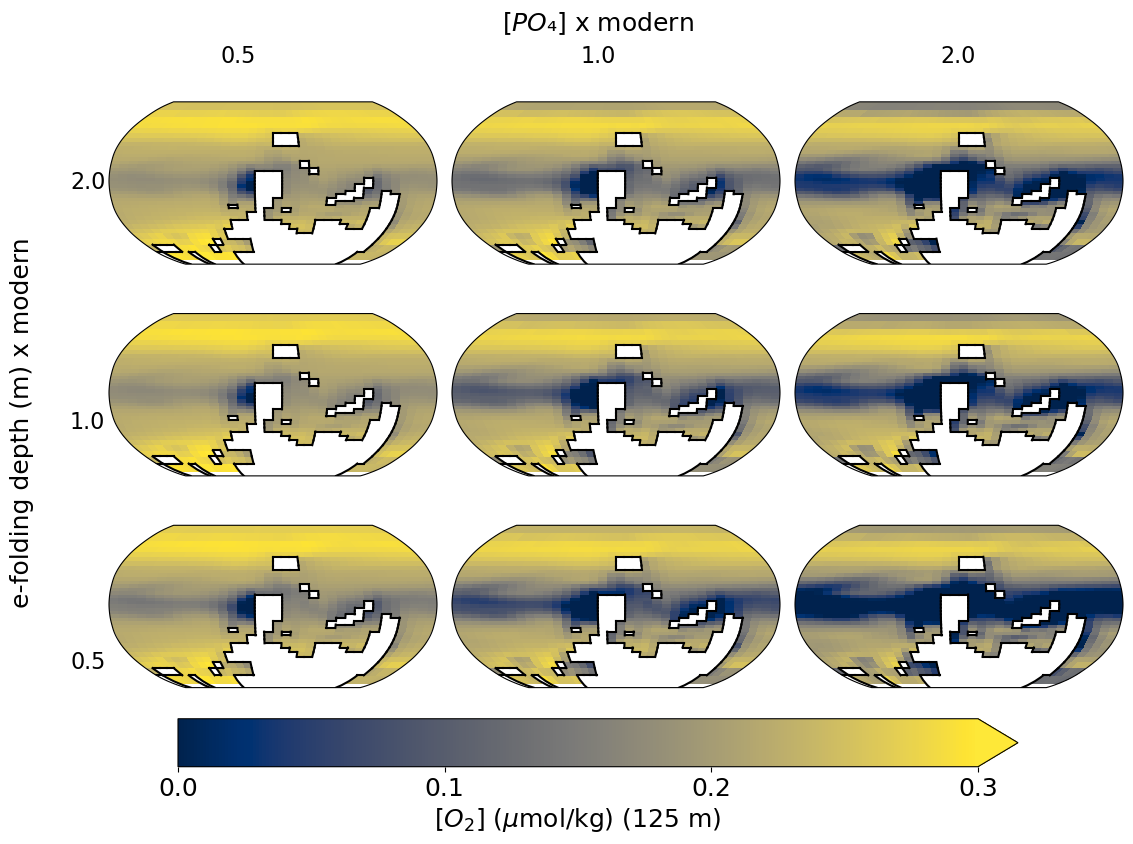

In [123]:
#Plot 2d mapview ensemble

fig = plt.figure(figsize=[12, 8]) #change second dimension depending on how spread outverticallyyou want the plots

#----------------------------------------------------------------------------------------------------
#subplots automaticaly set up to plot the 

#if you custom labels for each subplot define them here
#plots alphabet for the 
# labels =  [chr(i) for i in range(ord('a'), ord('z') + 1)] #this is to demonstrate how labeling subplots works using letters

# if you want to plot the m-score as the label run that section on Skill Metrics, uncomment and run this section
# mss1x = mss_values.reshape(-1, 5)
# mss1x = mss1x.astype(float)

# mss_strings = np.array2string(mss1x, formatter={'float_kind': lambda x: f"{x:.2f}"})
# mss_strings = mss_strings.replace('[', '').replace(']', '').replace('\n', '').split()
#------------------------------------------------------------------------------------------------------

#details about color scheme/bar
#If you want colorbar to range up to maxvalue select this, otherwise define vmax below
max_value = np.nanmax([np.nanmax(content) for content in plot_me_3d['content']]) # only need this if plotting max value of all ensembles 

#--------------------------------------------------------------------------------------------------------
#set the subplot grid a is y axis, b is x axis c is total 
#this makes a 5x5 grid
# a = 5
# b = 5
# c = 25

# #setting like this makes a horizontal 1 by 5 grid
# a = 1
# b = 1
# c = 6

# settling for 3x3 grid

a = 3
b = 3
c = 9

cbar_ax = fig.add_axes([0.15, 0.07, 0.7, 0.06]) # change last number to make it thicker


#set up ordering of subplots 
#this plots ensembles 00 thru 04 on bottom row, horizontally it is in reverse order bc of how plt.suplotworks
# subplot_order = [20,22,22,23,24,  
#                 15, 16,17,18,19, 
#                 10, 11, 12, 13, 14,
#                 5,6, 7,8,9, 
#                 0,1,2,3,4]

#3x3 grid 

subplot_order = [ 2,5,8,
                  1,4,7, 
                  0,3,6]

#this plots a single line 
# subplot_order = [0,1,2,3,4,5]

subplot_kws = dict(projection=ccrs.Robinson(), facecolor='#b0afae')
#------------------------------------------------------------------------------------------------------
#plot the ensemble here


for i, index in enumerate(subplot_order):
    row = plot_me_3d.iloc[index] #to plot map view of a specific layer of the ocean change to plot_me_3d and make sure in def tracer 3d this line is selected->value = value[1,:,:]
    file_name = row['file']

    data_array = row['content']

    #ax = plt.subplot(1, 5, i+1, **subplot_kws) # select if only plotting horizontal line
    ax = plt.subplot(a, b, i+1, **subplot_kws) # select if plotting a grid
    ax.set_facecolor('white')
    #change vmax= max_value or whatever makes sense for what you are plotting, vmax= 0.0003
    p = data_array.plot(x='lon', 
                        y='lat', 
                        vmin=0, 
                        vmax = 0.0003, 
                        cmap=cmap_O2, 
                        transform=ccrs.PlateCarree(), 
                        add_labels=False, 
                        add_colorbar=False, ax=ax)

    #subplot titles
    # ax.set_title(file_name, loc='left') # this plots the filenumber as the label, helpful to validate ordering
    #ax.set_title(labels[i], loc='center') # this plots your custom labels
    # ax.set_title(mss_strings[index], loc='center') # Use mss_strings with the original index

    #plot data overlay, if it is proxy data it is helpful to have the same vmin and vmax so it is colored the same, otherwise customize the way you want
    # plt.scatter(x=sites[:, 0], 
    #             y=sites[:, 1],
    #             c=sites[:,2], 
    #             vmin=0, vmax=4, 
    #             cmap=cmap_ICa, 
    #             edgecolor='black', 
    #             marker='o', 
    #             transform=ccrs.PlateCarree(), 
    #             s=25,
    #            zorder =3)

    #plot points as a single color
    # plt.scatter(x=sites[:, 0], y=sites[:, 1], facecolor='grey', edgecolor='black', marker='o', transform=ccrs.PlateCarree(), s=25)

    
    stepped_coastline_cGENIE(data_2d['lon_edges'], data_2d['lat_edges'],
                          ccrs.PlateCarree(),
                          topo_3d,
                          1.5,
                          zorder=41)
    
    # contour = data_array.plot.contour(ax=ax,
    #                          x='lon', y='lat',
    #                          levels=[1,2,3,4],
    #                          colors=['white'],
    #                          linestyles='dashed',
    #                          linewidths=1,
    #                          transform=ccrs.PlateCarree(),
    #                          add_labels=False,
    #                                  zorder = 2)
    
# plt.tight_layout(rect=[0, 0.1, 0.95, 0.97])
plt.tight_layout(rect=[0.08, 0.1, 0.95, 0.97])
#----------Labels
#plt.suptitle('',fontsize=16, x=0.5, y=0.98) #plot title

fig.text(0.5,0.99, '$[PO₄]$ x modern', ha='center', fontsize=18) #xlabel
# fig.text(0.5,0.99, '$pCO_2$ x preindustrial', ha='center', fontsize=18) #xlabel
# fig.text(0.01, 0.5, 'Atmospheric $pO_2$ x modern', va='center', rotation='vertical', fontsize=18) #ylabel
fig.text(0.01, 0.5, 'e-folding depth (m) x modern', va='center', rotation='vertical', fontsize=18) #ylabel

#x,y labels
# x = [0.75, 1.0, 2.5, 5.0, 7.5, 10]
x = [0.50 , 1.0 , 2.0]
# y = [0.8, 1.0, 1.2]
y = [0.50, 0.75, 1.0]

# x = [1.0, 1.1, 1.2, 1.3, 1.4]
# y = [0.8, 0.9, 1.0, 1.1, 1.2]


# #column labels (top) 3x3
for i, label in enumerate(x):
    fig.text(0.2 + i * 0.3, 0.95, label, ha='center', fontsize=16) # first arg is x placement of first of label string

# # # row labels (left)
# for i, label in enumerate(y):
    fig.text(0.06, 0.2 + i * 0.3, label, va='center', fontsize=16) # * number affects the spread of the labesls, 

#5x5 case 
# for i, label in enumerate(x): 
#     fig.text(0.1 + i * 0.2, 0.95, label, ha='center', fontsize=16) # first arg is x placement of first of label string

# # # row labels (left)
# for i, label in enumerate(y):
#     fig.text(0.05, 0.08 + i * 0.2, label, va='center', fontsize=16) # * number affects the spread of the labesls, 


#---------------colorbar -------------

cb = plt.colorbar( #use for scientific notation
    p, ticks=[0, 0.0001, 0.0002, 0.0003],cax=cbar_ax,
    extend="max", orientation='horizontal',
   format=mticker.FuncFormatter(lambda x, _: f'{x*1e3:.1f}')
)


# cb = plt.colorbar(p, cax=cbar_ax, extend="max",  orientation='horizontal', pad=0.01) #I/Ca $\\mu$mol/mol' format='%.1e',
cb.set_label(r'[$O_{2}$] ($\mu$mol/kg) (125 m)', fontsize=18)
# cb.set_label(r'Dissolved $O_2$ (mol/kg $\times 10^{-3}$)(~2125 m)', fontsize=20)
# cb.set_label('I/Ca $\\mu$mol/mol', fontsize=20)
# cb.set_label('SST ($^\circ$ C)', fontsize=20)
cb.ax.tick_params(labelsize=18) #change format .#f to get either more decimal places or e for scientific

#----------------
# plt.savefig('../figures/efoldingxPO4_mapview.png', dpi=300, bbox_inches='tight')

plt.show()


Plot map view of 2d fields ensemble stored in plot_me_3d. Here O2 at 2nd vertical depth is plotted  


### Ensemble zonal profile

Plot ensemble of zonal or meridional depth profiles of plot_me_3d

In [73]:
%%capture
##!!!!! 
# To plot this you need to go back to where plot_me_3d is defined and change the indexing from map view to profile view
# for sake of rendering output I do this here

df3d = {}
for name in glob.glob(r"../genie-output/manuscript_figure_files/PO4vsefolding/pO2xPO4_5x5.dat.*/biogem/fields_biogem_3d.nc"):#change path
  #print(name)
  data = xr.open_dataset(name)
  df3d[name] = data
sorted_dict = dict(sorted(df3d.items()))

df3d = pd.DataFrame(sorted_dict.items(), columns=['file', 'content'])

df3d['file'] = df2d['file'].str.split('dat').str[-1]

df3d['file'] = df2d['file'].str.split('biogem').str[0]


d_tracer3d = df3d.copy()

def tracer3d(field):
  for i in d_tracer3d['content'].index:
    value = d_tracer3d['content'][i]
    value = value[field]
    value = value.mean(dim = 'time')
    # value = value[2,:,:] # for 3d you must select layer, map view
    value = value[:,:,:] # if you want to plot vertical profile
    d_tracer3d['content'].iloc[i] = value

  return d_tracer3d

#plot_me_2d = tracer2d('ocn_ben_O2') # needed for calculating global areal extent benthic anoxia (way down below)
plot_me_3d = tracer3d('ocn_O2') #ocn_O2, misc_col_Dage (for ventilation age), 

##-----------------------

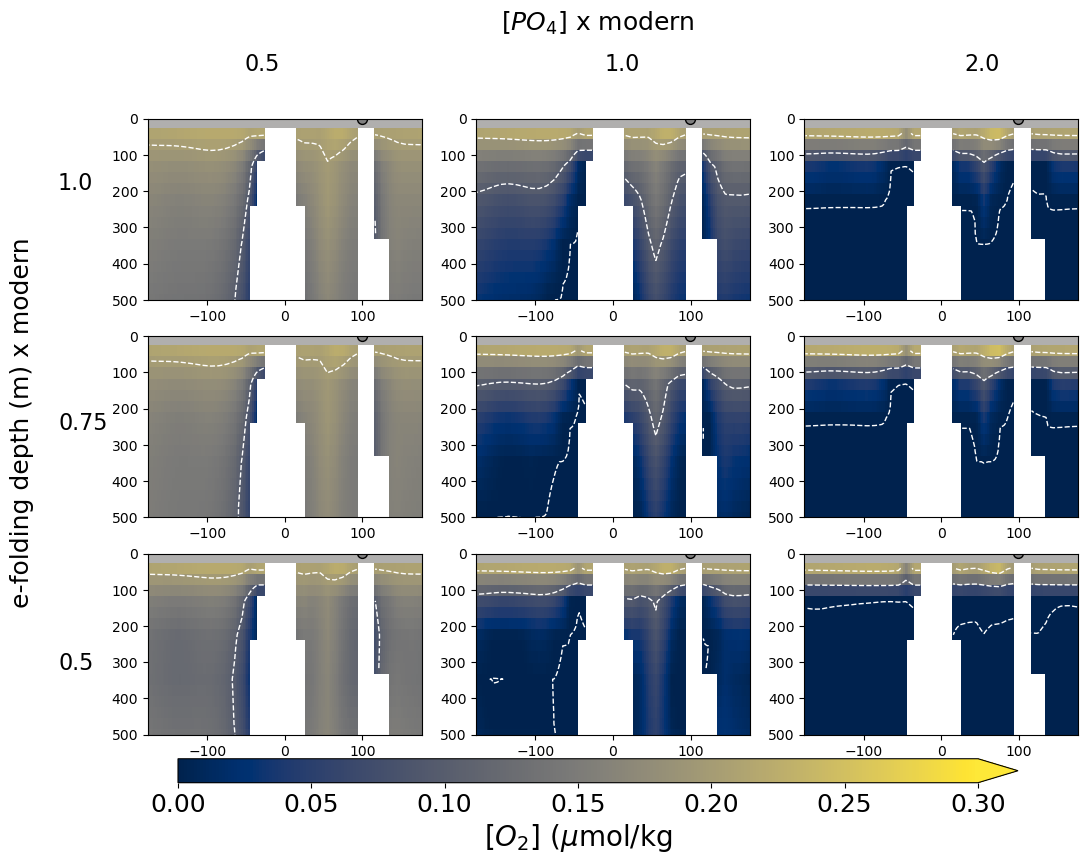

In [75]:
max_value = np.nanmax([np.nanmax(content) for content in plot_me_3d['content']])
#a = 5
#b = 5
#c = 25


a = 3
b = 3
c = 9

fig = plt.figure(figsize=[12, 8])
# fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()})
# Create a single colorbar axes at the bottom
cbar_ax = fig.add_axes([0.15, 0.05, 0.7, 0.03])  # Adjust position and size as needed

subplot_order = [ 2,5,8,
                  1,4,7, 
                  0,3,6]

subplot_kws = dict(facecolor='#b0afae')
# for index, row in plot_me_3d.iterrows():
for i, index in enumerate(subplot_order):
    row = plot_me_3d.iloc[index]
    file_name = row['file']
    data_array = row['content']

    ax = plt.subplot(3, 3, i + 1, **subplot_kws)

    # ---- zonal depth slice ----
    zonal_depth = data_array.isel(lat=17)

    new_zt = np.linspace(
        zonal_depth['zt'].values.min(),
        zonal_depth['zt'].values.max(),
        150
    )
    new_lon = np.linspace(
        zonal_depth['lon'].values.min(),
        zonal_depth['lon'].values.max(),
        150
    )

    # ---- interpolate ----
    interpolated_zero = zonal_depth.interp(
        zt=new_zt,
        lon=new_lon,
        method='linear'
    )

    # ---- plot ----
    p = interpolated_zero.plot(
        x='lon',
        y='zt',
        vmin=0,
        vmax=3e-4,
        cmap=cmap_O2,
        ylim=(500, 0),
        add_colorbar=False,
        add_labels=False,
        ax=ax
    )

    # ax.set_title(file_name, loc='left')

    contour = interpolated_zero.plot.contour(ax=ax,
                             x='lon', y='zt',
                             levels=[0,0.0001,0.0002,0.0003],
                             colors=['white'],
                             linestyles='dashed',
                             linewidths=1,
                             ylim=(500,0),
                             # transform=ccrs.PlateCarree(),
                             add_labels=False,
                             zorder = 2)


#----add sites
    
    plt.scatter(x=sites[:, 0], y=sites[:, 1], facecolor='grey', edgecolor='black', marker='o', s=50)
    # for plotting open circles
    #plt.scatter(x = ICa_long, y = ICa_lat, facecolor = 'none', edgecolor = 'black', marker = 'o', transform=ccrs.PlateCarree(), s = 50)
    c -= 1
    
#------- add axes labels and titles
fig.text(0.5,0.99, '$[PO_4]$ x modern', ha='center', fontsize=18) #xlabel
# fig.text(0.01, 0.5, 'Atmospheric ${p}O_2$ x modern', va='center', rotation='vertical', fontsize=18) #ylabel
fig.text(0.01, 0.5, 'e-folding depth (m) x modern', va='center', rotation='vertical', fontsize=18) #ylabel

#x,y labels
x = [0.5, 1.0, 2.0]
# y = [0.8, 1.0, 1.2]
y = [0.5, 0.75, 1.0]

# column labels (top)
for i, label in enumerate(x):
    fig.text(0.22 + i * 0.3, 0.94, label, ha='center', fontsize=16) # first arg is x placement of first of label string

# row labels (left)
for i, label in enumerate(y):
    fig.text(0.05, 0.2 + i * 0.3, label, va='center', fontsize=16) # * number affects the spread of the labesls, 



cb = plt.colorbar(p, cax=cbar_ax, extend="max",  orientation='horizontal', format=mticker.FuncFormatter(lambda x, _: f'{x*1e3:.2f}'),pad=0.3) #I/Ca $\\mu$mol/mol' format='%.1e',

cb.set_label('[$O_{2}$] ($\mu$mol/kg', fontsize=20)
cb.ax.tick_params(labelsize=18) #change format .#f to get either more decimal places or e for scientific


# plt.savefig('../figures/efoldingxPO4_profile.png', dpi=300, bbox_inches='tight')
plt.show()

### Ensemble Latitudinal gradients

In [ ]:
# Define custom colors
num_colors = len(plot_me_2d.content)  # Get the number of datasets
cmap = get_cmap("tab10", num_colors)  # Generate 'num_colors' distinct colors from 'tab10'
colors = [cmap(i) for i in range(num_colors)]  # Create a color list

# Define labels (adjust this based on your data)
labels = [f"Dataset {i+1}" for i in range(num_colors)]  

# Initialize plot
plt.figure(figsize=(10, 6))

# Get latitude values
lat = plot_me_2d.content[0]['lat']

# Loop through the dataset and plot each line
for i, x in enumerate(plot_me_2d.content):
    row_averages = x.mean(dim='lon')  # Average over longitude
    plt.plot(lat, row_averages, color=colors[i % len(colors)], label=labels[i])  # Assign colors and labels

# Add a grid
plt.grid(True)

# Create legend using custom Line2D objects
legend_lines = [Line2D([0], [0], color=c, linewidth=3, linestyle='-') for c in colors]
plt.legend(legend_lines, labels, loc='best', fontsize=10, bbox_to_anchor=(1.04, 1), borderaxespad=0)

# Set labels and title
plt.xlabel("Latitude")
plt.ylabel("Average Value")
plt.title("Latitudinal Gradient")

# Show plot
plt.show()


## Ensemble Time-Series

Plot time-series from an ensemble. For example if I want to plot a scatter plot of global SST vs benthic pO2 for an experiment of different radiative forcings (pCO2). 

In [ ]:
# Extract Time-Series Data

def extract_final_values(file_path, column_name):
    results = []  # List to store extracted values

    for path_to_file in glob.glob(file_path):
        column_names = ["Time (yr)", "Temperature (C)", "_surT (ice-free) (C)", "_benT (C) [> 2000 m]", "_surT (C)"]
       # column_names = ["time (yr)", "global total O2 (mol)",  "global mean O2 (mol kg-1)", "surface (ice-free) O2 (mol kg-1)",  "benthic [> 2000 m] O2 (mol kg-1)",  "surface O2 (mol kg-1)"]
        try:
            series_SST = pd.read_csv(path_to_file, sep ='\s+', names=column_names, skiprows=1)
        except Exception as e:
            print(f"Error reading {path_to_file}: {e}")
            continue  # Skip this file and move to the next one
        
        # Extract the last row's value for the given column
        if column_name in series_SST.columns:
            final_value = series_SST.iloc[-1][column_name]
        else:
            print(f"Warning: Column '{column_name}' not found in {path_to_file}")
            final_value = None  # Assign None if the column is missing
        
        # Append the filename and final value to the results list
        results.append({"file": os.path.basename(path_to_file), column_name: final_value})

    # Convert list to a DataFrame
    df_result = pd.DataFrame(results)
    
    return df_result


#ignore the warning, it works

In [ ]:
# calculate global averages of tracers

glob_path = (r"../genie-output/manuscript_figure_files/pCO2/pO2xPO4_5x5.dat.*/biogem/biogem_series_ocn_temp.res")
# glob_path = (r"../genie-output/manuscript_figure_files/pCO2/pO2xPO4_5x5.dat.*/biogem/biogem_series_ocn_O2.res")

column_name = "_surT (C)"
# column_name = "global mean O2 (mol kg-1)"


ensemble = extract_final_values(glob_path, column_name) # be sure to change the variable name for each set of data you want to save

print(ensemble)

pCO2 = [0.75, 1, 2.5, 5.0, 7.5, 10]
ensemble = ensemble.sort_values('file').reset_index(drop=True)  # sort to ensure consistent order
ensemble['pCO2'] = pCO2

plt.plot(ensemble['pCO2'], ensemble[column_name], marker='o')
plt.xlabel('pCO2 x preindustrial')
plt.ylabel('Global mean O2 (mol kg-1)')
plt.show()

# Skill Metrics & Statistics 


## Calculate M-scores and plot heatmap for ensemble

Important: plot_m2_2d needs to be the same as the proxy you are evaluating

Change the name of model_ICa to something more generic

**The first single netcdf file cell has to be run withthe same paleoconfiguration because this section uses site_coords and that is how it is calibrated to the paleoconfig**


In [101]:
%%capture
# untar_all_to_temp(r"..\genie-output\Ensemble\Devon370Ma_1xRemin_1xpCO2") # the temp folderis in src

df2d = {} # empy dictionary to save in

for name in glob.glob(r"..\genie-output\Ensemble\Devon370Ma_1xRemin_1xpCO2/Devon370Ma_1xRemin_1xpCO2.pO2xPO4_5x5b.dat.*/biogem/fields_biogem_2d.nc"): 

  data = xr.open_dataset(name)

  df2d[name] = data
  
sorted_dict = dict(sorted(df2d.items()))

df2d = pd.DataFrame(sorted_dict.items(), columns=['file', 'content'])
#print(df2d)

df2d['file'] = df2d['file'].str.split('dat').str[-1]

df2d['file'] = df2d['file'].str.split('biogem').str[0]

# define functions to subset 2d and 3d field data and save as objects plot_me_2d and plot_me_3d to work with

d_tracer = df2d.copy()

def tracer2d(field):
  for i in d_tracer['content'].index:
    value = d_tracer['content'][i]
    value = value[field]
    value = value.mean(dim = 'time') #use this if you only have one time slice
    #value = value[9] #use this if you have multiple time slieces to select the one you want
    #d_tracer['content'][i] = value
    d_tracer['content'].iloc[i] = value
    #d_tracer["content"][i] = value
  return d_tracer

plot_me_2d = tracer2d('proxy_sur_ICa') 

In [102]:

model_output = {}

for index, row in plot_me_2d.iterrows(): #save into plot_me_2d the field you want to perform statistical comparison to proxy data on
    x = row['content']
    #model_site = x.sel(lat=site_coords[:,1],lon=site_coords[:,0],method="nearest") 
    model_site = x.sel(lat=sites[:,1],lon=sites[:,0],method="nearest") 
    model_site = xr.DataArray.to_numpy(model_site)
    model_site = np.diag(model_site)
    model_output[index] = model_site 
#print(model_output)

This metric combines spatial variance and mean differences between modeled ($X$) and observed ($Y$) fields into a single value,

$$MSS = 1 - \frac{1}{\pi} \arcsin\left(\sqrt{\frac{mse}{V(X) + V(Y) + (\bar{G}_X - \bar{G}_Y)^2}}\right) \tag{1}$$

where $mse$ is the mean squared error, $V$ denotes variance, and $\bar{G}$ the mean (Table S1). Unlike regression-based approaches used previously, the arcsin transformation better accommodates non-Gaussian distributions and differing variances by normalizing values to a $0$ to $1$ scale, enhancing interpretability.

In [103]:
# Calculate M-Score

#subset the data values from proxy import section, this should work if you did or did not manually change the locations

proxy_ev_array = sites_KW[:,2]  # ev for event
proxy_bkg_array = sites[:,2]

#print(proxy_ev_array)

# Calculate the mean and variance of the proxy data 
v1 = proxy_ev_array.var()
v2 = proxy_bkg_array.var()

g1 = proxy_ev_array.mean()
g2 = proxy_bkg_array.mean()

#initialize calculate mscore
i = 0
mss_array={}

for row in model_output:
  #print(model_output)  
  #caluclate mean square error 

 #make sure to change this to either proxy_ev__array or proxy_bkg_array and that the below mscore is correctly chosen
  mse = np.square(np.subtract(model_output[i],proxy_bkg_array)).mean()  

   #mean_squared_error(ICa_KW_array, model_ICa[i], squared =True)
  v3 = model_output[i].var()

  g3 = model_output[i].mean()

  mscore = np.abs((2/np.pi)*np.arcsin(1-mse/(v2 + v3 + np.square(g3-g2)))) #bkg  
  # mscore = np.abs((2/np.pi)*np.arcsin(1-mse/(v1 + v3 + np.square(g3-g1)))) # KW
  mss_array[i]=mscore
  #print(mscore)

  i=i+1

mss_values = np.array(list(mss_array.values()))
#print(mss_values)
mss1x = mss_values.reshape(-1, 5)# need to change final digit depending on ensemble size (e.g. 3 for a 3 by 3)
mss1x = mss1x.astype(float)
print(mss1x)

# you will yield an error like arcsin out of bounds if you do not use the correct array for mse and mscore combination

[[0.30523847 0.14236035 0.00953405 0.00577142 0.03040246]
 [0.49361309 0.3830763  0.14841954 0.06973945 0.00646146]
 [0.34178161 0.4799958  0.42425036 0.20093143 0.10204664]
 [0.19883847 0.37480117 0.51312624 0.49942089 0.25118179]
 [0.13747196 0.22581536 0.41190109 0.54210544 0.54546926]]


In [104]:
#############################################################################
#If you want to plot the M-score as the subplot title this is where that is generated. 
#Rerun the cell that prints the ensemble map view with the mss_strings line uncommente

# Convert mss1x values to strings with two decimal places
mss_strings = np.array2string(mss1x, formatter={'float_kind': lambda x: f"{x:.2f}"})

# Remove brackets and extra characters
mss_strings = mss_strings.replace('[', '').replace(']', '').replace('\n', '').split()
###############################################################################

Setup to plot heatmap and save results. This first cell is also use to define the limits for benthic anoxia so if you don't want to plot mscore but want to plot benthic anoxia run this cell. This single cell is to maintain consistency when saving output to csv.

In [ ]:
#set x and y labels for the heatmap
#a
#y = ['x0.8','x0.9', 'x1.0','x1.1','x1.2'] #O2
#x = ['x0.2','x0.3', 'x0.4','x0.5','x0.6'] #PO4

#b
y = ['x0.8','x0.9', 'x1.0','x1.1','x1.2']
x = ['x0.7','x0.8', 'x0.9','x1.0','x1.1']

#c
#y = ['x0.8','x0.9', 'x1.0','x1.1','x1.2'] #O2
#x = ['x1.2','x1.3', 'x1.4','x1.5','x1.6'] #PO4

#d
#y = ['x0.3','x0.4', 'x0.5','x0.6','x0.7'] #O2
#x = ['x0.7','x0.8', 'x0.9','x1.0','x1.1']

#e
#y = ['x0.3','x0.4', 'x0.5','x0.6','x0.7'] #O2
#x = ['x1.2','x1.3', 'x1.4','x1.5','x1.6'] #PO4

#f
#y = ['x0.3','x0.4', 'x0.5','x0.6','x0.7'] #O2
#x = ['x0.2','x0.3', 'x0.4','x0.5','x0.6'] #PO4

In [ ]:
# plot heatmap
df_mss = pd.DataFrame(mss1x, columns = x, index = y)

df_mss = df_mss.sort_index(ascending=False)

#print(df_mss) # this prints the heat map as an array

sns.set()
ax=sns.heatmap(df_mss, cmap="flare", annot = True, fmt=".2f", vmin = 0,  vmax=0.6, label = 'Mscore')
ax.set(xlabel="PO4", ylabel="pO2")

plt.title("Mscore for I/Ca")
#plt.suptitle("KW")

# plt.savefig('../figures/pO2vsPO4_heatmap_kw.png', dpi=300, bbox_inches='tight')

plt.show()

## Save Results to datafile

Save mscore into csv file to be read in later. ** Make sure above heatmap looks *exactly* how you want it**

In [ ]:
# make structured dataframe to save datato

columns = ['State', 'pCO2','pO2', 'PO4','mscore', 'efolding','benthic_anoxia', "globe_avg_temp"]

results = pd.DataFrame(columns = columns)

print(df_mss) #reshape df_mss so that y goes in PO4 column, x in pO2


df_mss_reset = df_mss.reset_index().rename(columns={'index': 'pO2'})
results = df_mss_reset.melt(id_vars='pO2', var_name='PO4', value_name='mscore')
results['mscore'] = results['mscore'].round(2)

#add additional information to columns
results['State'] = "Kellwasser"
results['pCO2'] = "10x"
results['efolding'] = 'x0.5'
results['globe_avg_temp'] = ensemble['_surT (C)'] #from Ensemble Time-Series section

results['pO2'] = results['pO2'].str.lstrip('x').astype(float) #make pO2 and PO4 numerical
results['PO4'] = results['PO4'].str.lstrip('x').astype(float)

results



In [ ]:
# runfor first time save !!!!!!!!!

# results.to_csv('results/results_250107b.csv')

#if permission denied close the file

In [ ]:
# run to append, only run this if you do not need benthic anoxia, otherwise skip and run this line after 

# results.to_csv('results/results.csv', mode='a', index=True, header=False)

## Taylor Diagrams

Calculate and Plot correlations of the proxy data points to the nearest grid point

In [ ]:
# 
proxy_bkg_array = np.asarray(proxy_bkg_array, dtype=float)
std_obs = proxy_bkg_array.std()
std_obs

ensemble_std = []
ensemble_corr = []

for x in range(len(model_output)):
    model_array = np.array(list(model_output.values()))  
    std = model_output[x].std()

    std_norm = std/std_obs

    corr = np.corrcoef(proxy_bkg_array, model_output[x])
    corr = corr[0,1]
    ensemble_std.append(std_norm)
    ensemble_corr.append(std_norm)
  #print(std)
  #print(std_norm)
  #print(corr)

Important this package currently only plots in the first quadrant so you willwant to know if your coef are positive or negative by actualyl printing them. 

In [ ]:
# Create figure and Taylor Diagram instance
fig = plt.figure(figsize=(6, 6))
taylor = gv.TaylorDiagram(fig=fig, label='REF')
ax = plt.gca()

# Draw diagonal dashed lines from origin to correlation values
# Also enforces proper X-Y ratio
taylor.add_xgrid(np.array([0.6, 0.9]))

# Add model sets for p and t datasets
taylor.add_model_set(
    ensemble_std,
    ensemble_corr,
    fontsize= 10,  # specify font size
    xytext=(-3, 5),  # marker label location, in pixels
    color='red', # specify marker color
    marker='o', # specify marker shape
    facecolors='none', # specify marker fill
    s=50)  # marker size

# Add legend of ensemble names
#namearr = list(tas_rcp85.data_vars)
#taylor.add_model_name(namearr, fontsize=16)

# Add figure title
plt.title("Taylor Plot", size=26, pad=45)
taylor.add_contours(levels=np.arange(0, 1.1, 0.25),
                 colors='lightgrey',
                 linewidths=0.5)
#plt.show()

Regression analysis: Plot predicted vs Actual and residual plots for model output vs observed proxy data

In [ ]:
#plot just one simulation with residual plot 


df_reg = pd.DataFrame({'Actual': proxy_bkg_array.flatten(), 'Predicted': model_output[0].flatten()}) #if you want to plot just a single file replace Prdicted: data_2d

reg = LinearRegression().fit(df_reg[['Actual']], df_reg['Predicted'])
df_reg['Prediction_Line'] = reg.predict(df_reg[['Actual']])
score = reg.score(df_reg[['Actual']], df_reg['Predicted'])

coef = np.round(reg.coef_, 2)
# Create a 'hue' based on the actual values
df_reg['Hue'] = df_reg['Actual']

# Plot
plt.figure(figsize=(6, 4))
sns.set_theme(style = "ticks")
scatter = sns.scatterplot(data=df_reg, x='Actual', y='Predicted', hue='Hue', palette='viridis', alpha=0.8)

legend = scatter.legend_
legend.set_title(f"Coef = {coef} \n Actual Value" )

# Plot the regression line
plt.plot(df_reg['Actual'], df_reg['Prediction_Line'], color='red', label="Regression Line")
plt.plot([1,4], [1,4], 'k--')
plt.show()

In [ ]:
df_reg = pd.DataFrame({'Actual': proxy_bkg_array.flatten(), 'Predicted': model_output[0].flatten()}) 

reg = LinearRegression().fit(df_reg[['Actual']], df_reg['Predicted'])
df_reg['Prediction_Line'] = reg.predict(df_reg[['Actual']])
score = reg.score(df_reg[['Actual']], df_reg['Predicted'])

coef = np.round(reg.coef_, 2)
# Create a 'hue' based on the actual values
df_reg['Hue'] = df_reg['Actual']

# Plot
plt.figure(figsize=(8, 4))
plt.subplot(1,2,1)
sns.set_theme(style = "ticks")
scatter = sns.scatterplot(data=df_reg, x='Actual', y='Predicted', hue='Hue', palette='viridis', alpha=0.8)
plt.suptitle("Proxy vs Simulated Regression")
plt.title("Actual vs Predicted")
legend = scatter.legend_
coef_value = reg.coef_.item()  # Extract scalar value
coef_str = f"{coef_value:.3f}"  # Format with 4 decimal places



# Update legend title
legend.set_title(f"Coef = {coef_str} \n Actual Value")
# Plot the regression line
plt.plot(df_reg['Actual'], df_reg['Prediction_Line'], color='red', label="Regression Line")
plt.plot([1,4], [1,4], 'k--')

plt.subplot(1,2,2)
sns.residplot(x = proxy_bkg_array, y = model_output[0])
sns.move_legend(scatter, "upper left", bbox_to_anchor=(2.2, 1))
plt.title("Residuals")
plt.show()

## Plot Actual vs Predicted and residuals for ensemble. 


In [ ]:
# # Number of models
# num_models = len(model_output)

# # Create subplots (2 columns: scatter plot & residuals)
# fig, axes = plt.subplots(nrows=num_models, ncols=2, figsize=(12, 4 * num_models), sharex=True)

# # Ensure axes is a 2D array (even if num_models == 1)
# if num_models == 1:
#     axes = np.array([axes])  # Convert to a 2D array with one row

# sns.set_theme(style="ticks")

# # Loop through each model and create plots
# for n in range(num_models):
#     ax_scatter, ax_resid = axes[n]  # Extract subplot axes for the current model

#     df_reg = pd.DataFrame({
#         'Actual': proxy_bkg_array.flatten(), # the coordinates of whatever you are doing stats on here I want I/Ca 
#         # 'Actual': sites_SST[:,2].astype(float).flatten(),#here I want SST
#         'Predicted': model_output[n].flatten()
#     })

#     # Perform Linear Regression
#     reg = LinearRegression().fit(df_reg[['Actual']], df_reg['Predicted'])
#     df_reg['Prediction_Line'] = reg.predict(df_reg[['Actual']])
#     score = reg.score(df_reg[['Actual']], df_reg['Predicted'])
#     coef = np.round(reg.coef_.item(), 4)  # Convert to scalar, round to 4 decimals

#     # Sort values for smooth regression line
#     df_reg.sort_values(by='Actual', inplace=True)

#     # Create a 'hue' based on actual values
#     df_reg['Hue'] = df_reg['Actual']

#     # Scatter plot
#     scatter = sns.scatterplot(data=df_reg, x='Actual', y='Predicted', hue='Hue', palette='viridis', alpha=0.8, ax=ax_scatter)

#     # Adjust legend title
#     legend = scatter.legend_
#     legend.set_title(f"Coef = {coef} \n$R^2$ = {score:.2f} \n Model {n}")

#     # Plot the regression line
#     ax_scatter.plot(df_reg['Actual'], df_reg['Prediction_Line'], color='red', label="Regression Line")

#     # Plot the 1:1 reference line dynamically
#     min_val, max_val = df_reg['Actual'].min(), df_reg['Actual'].max()
#     ax_scatter.plot([min_val, max_val], [min_val, max_val], 'k--', label="1:1 Line")

#     ax_scatter.set_title(f"Model {n} - Actual vs Predicted")
#     ax_scatter.legend()

#     # Residual plot
#     sns.residplot(data=df_reg, x='Actual', y='Predicted', ax=ax_resid, scatter_kws={"alpha": 0.8})
#     ax_resid.set_title(f"Model {n} - Residual Plot")
#     ax_resid.axhline(0, linestyle="--", color="black", linewidth=1)

# plt.tight_layout()
# #plt.show()


# Calculation of Tracer Areal/Volume Extents

## Extent of bottom water anoxia (or other tracer of your choice)

Calculate the percent of seafloor that is anoxic. 

In [ ]:
# Calc ocean floor area

#this cell defines the seafloor where the seafloor is from the topography and cell area saved in data_2d

grid_topo = data_2d['grid_topo']
grid_topo=grid_topo.fillna(0)
grid_topo.plot(x="lon")

ocn_floor=np.ma.masked_where(grid_topo == 0, grid_topo,copy = True)

#ocn_floor=np.ma.masked_where((grid_topo>174.75186) |(grid_topo == 0), grid_topo,copy = True)

#print(ocn_floor)

#ocn.plot(x="lon")
grid_area = data['grid_area']
#grid_area.plot(x="lon")

grid_area_ocn = np.ma.masked_where(ocn_floor.mask== True, grid_area,copy =True)
#print(ocn_floor)


In [ ]:
#set the threshold for anoxia you want to calculate
anoxia_thres = 0
#anoxia_thres = 0.000006  # hypoxia threshold
#anoxia_thres = 0.0000072 # Ld50

<div class="alert-warning">
<b>Important</b> you must save the variable 'ocn_ben_O2' into plot_me_2d. Cross check that numbers you get for benthic anoxia are realistic with the 3-D ensemble map view 
</div>

In [ ]:
%%capture
df2d = {}

#this is a good one for examples, keep for git hub page but rename 
for name in glob.glob(r"temp/Devon370Ma_1xRemin_1xpCO2.pO2xPO4_5x5b.dat.*/biogem/fields_biogem_2d.nc"): 
  data = xr.open_dataset(name)

  df2d[name] = data
  
sorted_dict = dict(sorted(df2d.items()))

df2d = pd.DataFrame(sorted_dict.items(), columns=['file', 'content'])
#print(df2d)

df2d['file'] = df2d['file'].str.split('dat').str[-1]

df2d['file'] = df2d['file'].str.split('biogem').str[0]
d_tracer = df2d.copy()
plot_me_2d = tracer2d('ocn_ben_O2')

In [ ]:

benthic_anoxia = {}
for index, row in plot_me_2d.iterrows():
  b_O2 = row['content']
  #print(row['file'])  
    
  b_O2=b_O2.where(b_O2>0, )
  b_O2=b_O2.fillna(0)
    #print(b_O2_t)
  seafloor_anoxic_area = np.ma.masked_where(b_O2>anoxia_thres, grid_area_ocn,copy = True)
    #print(seafloor_anoxic_area)
  seafloor_anoxia_abs = np.ma.sum(seafloor_anoxic_area)
  seafloor_anoxia_per =seafloor_anoxia_abs/np.ma.sum(grid_area_ocn)*100

  benthic_anoxia[index]=seafloor_anoxia_per

sorted_dict = dict(benthic_anoxia.items())
#sorted_dict

df_anoxia = pd.DataFrame(sorted_dict.items(), columns=['file', '%anoxia'])
print(df_anoxia)

Save benthic anoxia into csv file. When doing really large ensembles can save value into csv file by appending ensemble and associaed value. This is saved linearly because later on it will be used to iteratively calculate the possible differences that fit a certain range, so be carfule when appending that you assign the correct ensemble # and you know what you assigned that #

I recomend commenting out the tocsv to avoid overwriting data

In [ ]:
# Plot % benthic anoxia a heat map

#
y = ['x0.8','x0.9', 'x1.0','x1.1','x1.2']
x = ['x0.7','x0.8', 'x0.9','x1.0','x1.1']


df_anoxia = pd.Series(benthic_anoxia).sort_index()
anoxia = df_anoxia.values.reshape(-1, 5)

df_anoxia_2d = pd.DataFrame(anoxia, columns=x, index=y)
sns.set()
ax=sns.heatmap(anoxia, cmap="crest", annot = True, fmt=".1f",  vmin = 0,  vmax=80)
ax.set(xlabel="$xPO_4$", ylabel="$xO_2$")

plt.suptitle("% Seafloor Anoxia")
plt.title("0 $\\mu$ mol/mol $O_2$ threshold")

plt.show()

In [ ]:
#print(anoxia)
anoxia = anoxia.round(2)
anoxia = pd.DataFrame(anoxia, columns=x, index=y)
anoxia_reshape = anoxia.reset_index().rename(columns={'index': 'pO2'})
anoxia_reshape.fillna(0, inplace=True) # set nan to 0
anoxia_reshape = anoxia_reshape.melt(id_vars='pO2', var_name='PO4', value_name='ben_anoxia')

anoxia_reshape['pO2'] = anoxia_reshape['pO2'].str.lstrip('x').astype(float)
anoxia_reshape['PO4'] = anoxia_reshape['PO4'].str.lstrip('x').astype(float)

#print(anoxia_reshape)

results['ben_anoxia'] = anoxia_reshape['ben_anoxia']

results

In [ ]:
# save to results.csv

# results.to_csv('../results/results_example.csv')

# if Permission Denied it means the file is open, so close it

In [ ]:
# run to append
# results.to_csv('results/results_example.csv', mode='a', index=True, header=False)


## Global averages binned by latitude or depth

Plot average dissolved O2 for latitudinal bands (e.g., tropical, extratropical, temperate, polar regions). This may be helpful in recognizing where oxygen depletion is occuring between scenarios. This section is set up to process only one simulation at a time. If you have an ensemble you can subset each individually as demonstrated below and repeat.


<div>
<img src="../images/depths.jpg" width="500"/>
</div>

zt values correspond to layer centers and for that reason the below calculationg is off ever so slightly (x10-5 digit) but really not enough to be a big deal.

<div>
<img src="../images/zt_16_level.png" width="200"/>
</div>

In [ ]:
# save each simulation of ensemble independently into new variable 

#O2_conc = plot_me_3d['content'][5] #set plot_me_3d to ocn_O2, and index which you want to calculate 

#single run

O2_conc = data_3d['ocn_O2']

In cGENIE shallow is the top most layer (zt = 1) and benthic/deep is >2000 m (zt = 12-16). This is what is printed out in the time series output files if you want to cross check. The code is correctly set up to calculate that below. However, if you want to say define Shallow as 0 to 228 m (epipelagic zone), Intermediate 228 to 1040 m (~thermocline), Deep 1040 to 4604 m then you can do that by changing the zt values ranges below.

In [ ]:
shallow = np.array([1]) #zt values 
intermediate = np.array([2, 3, 4, 5,6,7,8,9,10,11])
deep = np.array([12,13,14,15, 16])


zts = O2_conc.zt.values #
print(O2_conc.zt.values)

dz = np.diff(zts) 
dz # thicknesses of each layer, notice how they increase with depth

<div class="alert-warning">
<b>Important</b> that plot_me_3d has the indexing values[:,:,:] selected 
    if you get -> ValueError: Dimensions {'zt'} do not exist. Expected one or more of ('lat', 'lon')
</div>

In [ ]:
#calculate global average, Single run

global_mean = O2_conc.mean()
print(f"the global average [O2] is {global_mean.values}")

#calculae global average between a range of depths 

shallow_mean = O2_conc.isel(zt = shallow-1).mean() #isel() selects by index starting at 0 so you need to subtract 1 
print(f"the shallow average [O2] is {shallow_mean.values}")

deep_mean = O2_conc.isel(zt = deep-1).mean() #isel() selects by index starting at 0 so you need to subtract 1 
print(f"the global deep water average [O2] is {deep_mean.values}")

intermediate = 3*global_mean.values - shallow_mean.values - deep_mean.values

print(f"the global intermediate deph average is [O2] is {intermediate}")

# these values should be similar to the time series output file for global, surface and benthic O2

In [ ]:
# calculate global average of tracer saved above at specific discrete depth

zt_values = [1, 5, 13]  # depths to calculate for, see plot above
average_o2_conc = {}
m= {}
for zt in zt_values:
  # Assuming zt corresponds to a depth index in the 'plot_me_3d' dataset.
  # Replace this if zt corresponds to a different dimension or variable
  try:
    o2_zt = O2_conc.isel(zt=zt-1)  
    average_o2 = o2_zt.mean().item()
    average_o2_conc[zt] = average_o2
    m = ['40 m', '482 m', '3282 m']
    #print(f"the average [O2] at depth {m} is ", average_o2_conc[zt])
  except KeyError:
    print(f"zt value {zt} not found in dataset.")
    average_o2_conc[zt] = None # Or handle the missing data differently
for i, txt in enumerate(m):
   print(f"the global average [O2] at depth {txt} is {average_o2_conc[zt_values[i]]:.6f}")


Calculate the latitudinal oxygen gradient for specific depths (not averaged over depth ranges). This as default calculates the average and plots a point per 20 degree band. If you want more or less points just change latitude_constraits. Right now only calculates for one 

In [ ]:
# modify this to plot two simulations and for zt to be zt = 1 to 3

#calculate dissolved oxygen by latitude at a specific depth
#zt_values = [1, 3, 5, 7, 9, 11, 13, 15]  # Choose the depth indices you want 
#zt_values = [1, 5, 13] # shallow, int, deep 

latitude_constraints = [(-80, -60), (-60, -40), (-40, -20), (-20, 0), 
                        (0, 20), (20, 40), (40, 60), (60, 80)]

plt.figure(figsize=(10, 6))
results_matrix = [] # assign space to store results in (outside loop so it can be saved to csv)

# Loop over each zt depth level
for zt in zt_values:
    lat_mids = []
    o2_averages = []
    
    for lat_min, lat_max in latitude_constraints:
        try:
            o2_zt = O2_conc.isel(zt=zt - 1) # because indexing starts at zero :=)
            o2_zt_constrained = o2_zt.where(
                (O2_conc.lat >= lat_min) & (O2_conc.lat <= lat_max),
                drop=True
            )
            average_o2 = o2_zt_constrained.mean().item() 

            lat_mids.append((lat_min + lat_max) / 2)
            o2_averages.append(average_o2)
           # print(f"The global average [O2] at zt index {zt-1} ({zt}th level) "       # if you want to print specific values 
           #   f"between {lat_min} and {lat_max} degrees latitude is: {average_o2:.7f}") # in lieu of me coding something to save as a csv ...
           
          
        
        except KeyError:
            print(f"zt value {zt} not found in dataset.")
        except AttributeError:
            print(f"Latitude variable not found in dataset or incorrect latitude range provided.")

        
    # Plot for this depth
    plt.plot(lat_mids, o2_averages, marker='o', label=f'Depth level {zt} (index {zt-1})')


# Final plot setup
plt.xlabel("Latitude (degrees)")
plt.ylabel("Average Dissolved O₂")
plt.title("Meridional Average Dissolved O₂ at Various Depth Levels")
plt.legend(title='zt levels')
plt.grid(True)
plt.tight_layout()

#save data as csv
plt.show()


In [ ]:
shallow = [0,1,2,3] # top 350 m
bkg_O2 = bkg_3d['ocn_O2']
kw_O2 = kw_3d['ocn_O2']
#shallow_mean_O2 = bkg_O2.isel(time = 0, zt = shallow).mean() 
#shallow_mean_kw = kw_O2.isel(time = 0, zt = shallow).mean() 

bkg_mean= (
    bkg_O2.isel(time=-1, zt = shallow)               # final time slice
           .mean(dim=("lat", "lon", "zt"), skipna=True)
           .item()
)


kw_mean= (
    kw_O2.isel(time=-1, zt = shallow)               # final time slice
           .mean(dim=("lat", "lon", "zt"), skipna=True)
           .item()
)

print(bkg_mean)
print(kw_mean)

In [ ]:
#calculate dissolved oxygen by latitude at a specific depth
zt = [0,1,2, 3]

shallow_mean_O2_bkg = bkg_O2.isel(time = 0, zt = zt).mean()
shallow_mean_O2_kw = kw_O2.isel(time = 0, zt = zt).mean()
O2_change = shallow_mean_O2_bkg - shallow_mean_O2_kw



zt_values = [2]  # Choose the depth indices you want 

latitude_constraints = [(-80, -60), (-60, -40), (-40, -20), (-20, 0), 
                        (0, 20), (20, 40), (40, 60), (60, 80)]

plt.figure(figsize=(10, 6))
results_matrix = [] # assign space to store results in (outside loop so it can be saved to csv)

# Loop over each zt depth level
for zt in zt_values:
    lat_mids = []
    o2_averages_bkg = []
    
    for lat_min, lat_max in latitude_constraints:
        try:
            o2_zt = bkg_O2.isel(zt=zt) # because indexing starts at zero :=)
            
            o2_zt_constrained = o2_zt.where(
                (bkg_O2.lat >= lat_min) & (bkg_O2.lat <= lat_max),
                drop=True
            )
            average_o2 = o2_zt_constrained.mean().item() 

            lat_mids.append((lat_min + lat_max) / 2)
            o2_averages_bkg.append(average_o2)
           # print(f"The global average [O2] at zt index {zt-1} ({zt}th level) "       # if you want to print specific values 
           #   f"between {lat_min} and {lat_max} degrees latitude is: {average_o2:.7f}") # in lieu of me coding something to save as a csv ...
           
        except KeyError:
            print(f"zt value {zt} not found in dataset.")
        except AttributeError:
            print(f"Latitude variable not found in dataset or incorrect latitude range provided.")

for zt in zt_values:
    lat_mids = []
    o2_averages_kw = []
    
    for lat_min, lat_max in latitude_constraints:
        try:
            o2_zt = kw_O2.isel(zt=zt) # because indexing starts at zero :=)
            o2_zt_constrained = o2_zt.where(
                (kw_O2.lat >= lat_min) & (kw_O2.lat <= lat_max),
                drop=True
            )
            average_o2_kw = o2_zt_constrained.mean().item() 

            lat_mids.append((lat_min + lat_max) / 2)
            o2_averages_kw.append(average_o2_kw)
           # print(f"The global average [O2] at zt index {zt-1} ({zt}th level) "       # if you want to print specific values 
           #   f"between {lat_min} and {lat_max} degrees latitude is: {average_o2:.7f}") # in lieu of me coding something to save as a csv ...
           
        except KeyError:
            print(f"zt value {zt} not found in dataset.")
        except AttributeError:
            print(f"Latitude variable not found in dataset or incorrect latitude range provided.")          



    # Plot for this depth
    plt.plot(lat_mids, o2_averages_bkg,  marker='o', label= "Background")
    plt.plot(lat_mids, o2_averages_kw, linestyle = "dashed", marker='o', label ="Kellwasser")

plt.text(
    0.05, 0.8, 
    f"Average Global Dissolved O2 for top 350 m \n Background: {shallow_mean_O2_bkg:.4e} mol kg$^{{-1}}$ \n Kellwasser: {shallow_mean_O2_kw:.4e} mol kg$^{{-1}}$ \n Change: {O2_change:.4e} mol kg$^{{-1}}$", 
    transform=plt.gca().transAxes
)

# Final plot setup
plt.xlabel("Latitude (degrees)")
plt.ylabel("Average Dissolved O₂")
plt.title(f"Zonal Average Dissolved O₂ at {int(bkg_O2.isel(zt=zt_values)['zt'].values)} m")

plt.legend(title='')
plt.grid(True)
plt.tight_layout()

# plt.savefig("../figures/lat_dissolved_O2.png")

plt.show()


# File Saving 

## Save to pdf

Save multiple different types plots or plots from different runs into a single pdf. For this you will want to run and save the plots you want into an object into Figure directory, assign the name to plot# in below code and run it. Change plot function to rearrange plots into desired order 

Plot on separate pages

In [ ]:
pp = PdfPages('../figures/pdf_output.pdf')

plot1 ="../figures/lat_dissolved_O2.png"
plot2 ="../figures/O2_diff_plot.png"
# plot3 ="../figures/lat_sst.png"
# plot4 ="../figures/temp_diff_plot.png"

def function_plot(image_path):
    img = mpimg.imread(image_path)
    plt.figure(figsize=(8, 6))
    plt.axis('off')  # Turn off axes if you just want the image
    pp.savefig()
    plt.close()  # Close the figure to avoid overlap

# Save both images to the PDF
function_plot(plot1)
function_plot(plot2)

pp.close()

Plot on same pdf page. The difference is just where you define the figuresize and save it (outside of function). 

In [ ]:
pp = PdfPages('../figures/pdf_output.pdf')

plot1 ="../figures/lat_dissolved_O2.png"
plot2 ="../figures/O2_diff_plot.png"


plt.figure(figsize=(10, 8))

def function_subplot(image_path, position):
    img = mpimg.imread(image_path)
    plt.subplot(2,2,position)
    plt.imshow(img)
    plt.axis('off')  # Turn off axes if you just want the image
    
    #plt.close()  # Close the figure to avoid overlap

# Save both images to the PDF

function_subplot(plot1, 1)
function_subplot(plot2, 2)

plt.tight_layout()
pp.savefig()
pp.close()
plt.close()

## Gifs

Make a gif of displaying different time slices or dataoverlay

In [ ]:
# filepaths
# fp_in = "Figures/GIFS/*.png" # save into a folder called GIF the files you want to combine into a gif
# fp_out = "Figures/GIFS/ICa_mscore_movie.gif"

# use exit stack to automatically close opened images
with contextlib.ExitStack() as stack:

    # lazily load images
    imgs = (stack.enter_context(Image.open(f))
            for f in sorted(glob.glob(fp_in)))

    # extract  first image from iterator
    img = next(imgs)

    # https://pillow.readthedocs.io/en/stable/handbook/image-file-formats.html#gif
    img.save(fp=fp_out, format='GIF', append_images=imgs,
             save_all=True, duration=1000, loop=0) # duration is ms